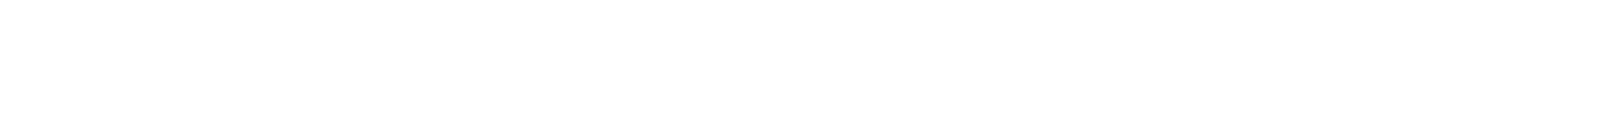

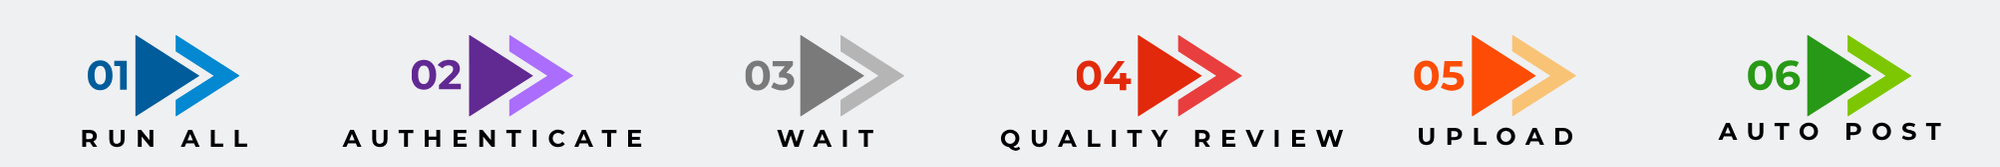

# **6 Steps to Use This Tool**

### **1. Run All**
In the menu bar, click **Runtime → Run All**.

### **2. Authenticate**
After libraries are installed, authenticate **twice** to enable Google Auth API and Google Drive mount.

### **3. Wait**
Let the script finish. A **ZIP file** containing all generated BA purple boxes in PowerPoint will download automatically.  
Extract it to your PC and follow the included instructions for **Quality Review and Animation**.

### **4. Quality Review**
Check headers, subheaders, logos, and other content to ensure quality. Do **not** rely solely on AI.

### **5. Upload**
In Colab, run the last part of the script and upload your **PPTX** and **GIF** BAs.

### **6. Auto Post**
Wait for the script to finish uploading files to [**Google Drive**](https://drive.google.com/drive/u/0/folders/1Z8m_0t4xeyxlz2oJug3aCMbj4z2-Xg9W), the [**gSlides master file**](https://docs.google.com/presentation/d/1tbWbj_6hjoutRejfxeJsbmaV3-aeGu3rwkvmCb9gKxk/edit?slide=id.g39e0f4575e4_1_813#slide=id.g39e0f4575e4_1_813), the [**SI/BA Tracker**](https://docs.google.com/spreadsheets/d/1UbMhCzsBQ9AJ0_yZRzuvaYf-y5SL4cjrdCBPWvkUKZI/edit?gid=727490561#gid=727490561&fvid=1357167152), and [**LinkedIn Scheduler**](https://docs.google.com/spreadsheets/d/1vPpE1V518gf7YGPxnYv03SEC03MwDD4rDbKb09Fw0do/edit?gid=0#gid=0).

# **End**


###    

# **Step 1 - Run All**
In the menu bar, click Runtime → Run All.

In [ ]:
#@title # Backdating Logic
#@markdown ## Filter Settings
#@markdown ### Enter **0** for normal operation.
#@markdown ### Enter a number greater than **0** to look back that many days.
#@markdown ### Example: Setting it to **2** will make the script use data from 2 days ago.

#@markdown **Adjustment Slider:**
backdate_days = 0 #@param {type:"slider", min:0, max:30, step:1, width:10000}

# The logic below will use the value selected above
print(f"Script is currently set to look back {backdate_days} days.")

# Example of how the variable is used in your code:
# target_date = datetime.now() - timedelta(days=backdate_days)

Script is currently set to look back 0 days.


# **Step 2 - Authenticate**

In [ ]:
# @title CELL A: Install Libraries and Define Imports

# ===========================
# 1. SYSTEM DEPENDENCY FIX (REQUIRED FOR IMGKIT)
# ===========================
print("⚙️ Installing system dependency wkhtmltopdf for imgkit...")
!apt-get update -qq > /dev/null
!apt-get install -y wkhtmltopdf > /dev/null

print("✅ wkhtmltopdf installed.")
print("---")

# ===========================
# 2. PYTHON PACKAGE LIST
# ===========================
packages_to_install = [
    # Image Generation Dependency
    "imgkit",
    "dataframe-image",
    "kaleido==0.1.*",
    "cairosvg",

    # Document/File Handling and Scraping
    "requests", "xlsxwriter", "python-pptx", "python-docx",
    "beautifulsoup4", "cloudscraper",

    # Google/Cloud specific helpers
    "gspread_dataframe",
    "google-auth-oauthlib", "google-auth-httplib2",

    # Other specific libraries
    "openai", "PyDrive"
]

# ===========================
# 3. INSTALL PYTHON PACKAGES
# ===========================
import subprocess
import sys
from tqdm.notebook import tqdm

print("⚙️ Installing Python packages...")
for pkg in tqdm(packages_to_install, desc="Installing Python packages", unit="pkg"):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print("---")
print("✅ All required Python libraries installed.")

# ===========================
# 4. IMPORTS (Necessary for subsequent cells)
# ===========================
import pandas as pd
import gspread
from google.colab import auth, drive
from googleapiclient.discovery import build
import google.auth
from IPython.display import Image, display
import imgkit


⚙️ Installing system dependency wkhtmltopdf for imgkit...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
✅ wkhtmltopdf installed.
---
⚙️ Installing Python packages...


Installing Python packages:   0%|          | 0/15 [00:00<?, ?pkg/s]

---
✅ All required Python libraries installed.


In [ ]:
# @title CELL B: Authentication, Drive Mounting, and Configuration
# ===========================
# AUTHENTICATION
# ===========================
import gspread
from google.colab import auth, drive
from googleapiclient.discovery import build
import google.auth
# Authenticate the user for API access (required for gspread and drive_service)
auth.authenticate_user()
creds, _ = google.auth.default(scopes=['https://www.googleapis.com/auth/drive'])
gc = gspread.authorize(creds)
drive_service = build('drive', 'v3', credentials=creds)

# NEW: Get the name of the person running the script
user_info = drive_service.about().get(fields="user(displayName)").execute()
BA_NEWS_EDITOR = user_info.get('user', {}).get('displayName', 'Unknown User')

print("🔑 Google user authenticated.")

# ===========================
# CONFIG
# ===========================
# shared drive folder ID (Ensure this is correct)
PARENT_FOLDER_ID = "1Z8m_0t4xeyxlz2oJug3aCMbj4z2-Xg9W"

# ===========================
# MOUNT DRIVE
# ===========================
# Mount Google Drive to /content/drive
drive.mount('/content/drive', force_remount=True)

print(f"✅ Environment ready. Drive mounted and authenticated. Parent Folder ID set to: {PARENT_FOLDER_ID}")
print(f"👤 Editor identified as: {BA_NEWS_EDITOR}")

🔑 Google user authenticated.
Mounted at /content/drive
✅ Environment ready. Drive mounted and authenticated. Parent Folder ID set to: 1Z8m_0t4xeyxlz2oJug3aCMbj4z2-Xg9W
👤 Editor identified as: Sam Caasi


In [ ]:
#@title Runtime Start Time



# Put this at the very top of your Colab
import time
global_start_time = time.time()
global_start_time

1786080434.3930712

# **Step 3 - Wait**

# STEP 3.1 = Data from RSS FEED



In [ ]:
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
import io, json, os

# Authenticate to Google
auth.authenticate_user()
drive_service = build('drive', 'v3')

# Your file ID from Google Drive
FILE_ID = "1MW4L2WgpoZ30Jqzdqlg8a6c8_Xwnm809"

# Download the JSON config
request = drive_service.files().get_media(fileId=FILE_ID)
fh = io.BytesIO()
downloader = MediaIoBaseDownload(fh, request)
done = False
while not done:
    status, done = downloader.next_chunk()

fh.seek(0)
cfg = json.load(fh)

# Set both environment variables
os.environ["OPENAI_API_KEY"] = cfg.get("OPENAI_API_KEY", "")
os.environ["API_KEY"] = cfg.get("API_KEY", "")

print("OPENAI_API_KEY loaded:", bool(os.environ["OPENAI_API_KEY"]))
print("API_KEY loaded:", bool(os.environ["API_KEY"]))

OPENAI_API_KEY loaded: True
API_KEY loaded: True


In [ ]:
# #@title High Scoring Firm

# import requests
# import pandas as pd

# # Replace with your actual API token
# API_TOKEN = os.getenv("API_KEY")

# # API endpoint
# url = "https://api.securityscorecard.io/portfolios/899280cc-ce44-5859-b426-f000c4dc26a8/companies?grade=A"

# # Headers
# headers = {
#     "Authorization": f"Token {API_TOKEN}",
#     "accept": "application/json; charset=utf-8"
# }

# # Request
# response = requests.get(url, headers=headers)
# response.raise_for_status()
# data = response.json()

# # Extract entries
# entries = data.get("entries", [])

# # Convert to DataFrame
# df_highscores = pd.DataFrame(entries)[["name", "domain", "industry", "score"]]
# df_highscores.rename(columns={
#     "name": "Company Name",
#     "domain": "Domain",
#     "industry": "Industry",
#     "score": "Score"
# }, inplace=True)

# # Display DataFrame
# df_highscores


#@title High Scoring Firm

import pandas as pd
import gspread
from google.colab import auth
import google.auth

# Authenticate with Google
auth.authenticate_user()
creds, _ = google.auth.default()
gc = gspread.authorize(creds)

# Open Google Sheet by URL (Replace with your actual URL)
spreadsheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1fCkhiefnp4rIl-VfQJSK1IxATbocOfam-fSQ1B3crug/edit?gid=952035054#gid=952035054")

# Select the worksheet
worksheet = spreadsheet.worksheet("HIGH SCORING FIRM")

# Get all values (evaluated, not formulas)
data = worksheet.get_all_values()

# Convert to DataFrame
df_sheet = pd.DataFrame(data[1:], columns=data[0])  # Skip header row

# Extract entries and apply exact original dataframe naming convention
df_highscores = df_sheet[["Company Name", "Domain", "Industry", "PERCENTILE"]].copy()

df_highscores.rename(columns={
    "PERCENTILE": "Score"
}, inplace=True)

# Make the data in the industry small caps
df_highscores["Industry"] = df_highscores["Industry"].str.lower()

# Display DataFrame
df_highscores

,Company Name,Domain,Industry,Score
0,Microdevice,microdevice.it,manufacturing,99
1,Vettrak,vettrak.com.au,information services,92
2,S Food,s-food.co.kr,manufacturing,93
3,Faab,faab.in,unknown,99
4,Badgerpopcorn,badgerpopcorn.com,manufacturing,92
...,...,...,...,...
3558,BeiGene,beigene.com,pharmaceutical,95
3559,Pncbank,pncbank.com,non profit,91
3560,American Express,americanexpress.com,financial services,92
3561,Engie,engie.com,energy,94


In [ ]:
#@title  Group by Industry and aggregate domains by score
import pandas as pd

# Group by Industry and aggregate domains sorted by Score
df_highscores_industry = (
    df_highscores
    .iloc[:, [1, 2, 3]]  # col 0 = Domain, col 7 = Industry, col 3 = Score
    .dropna(subset=["Domain"])
    .groupby("Industry", dropna=False)
    .apply(lambda g: g.sort_values("Score", ascending=False)["Domain"].unique())
    .reset_index(name="Domain")
)

# Turn list into bracketed string
df_highscores_industry["Domain"] = df_highscores_industry["Domain"].apply(lambda lst: "[" + ", ".join(lst) + "]")

# Add Count column (length of unique domains per industry)
df_highscores_industry["Count"] = df_highscores_industry["Domain"].apply(lambda x: x.count(",") + 1 if x != "[]" else 0)

df_highscores_industry


/tmp/ipykernel_1220/1280335375.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values("Score", ascending=False)["Domain"].unique())


,Industry,Domain,Count
0,business services,"[daintta.com, securebug.se, hourly.com, instin...",15
1,construction,"[tishmanspeyer.com, aspenpumps.com, edenbeck.c...",70
2,consumer services,"[larochelle-tourisme.com, consolidatedcoin.com...",3
3,cultural,[hillsidelibrary.org],1
4,education,"[school.it, wit.ie, lit.ie, itcarlow.ie, e92pl...",54
5,energy,"[spiredigital.com, peoplesenergy.co.uk, northe...",104
6,energy utilities waste treatment,"[trailridgeenergy.com, allcoastllc.com, moreld...",4
7,entertainment,"[insightpropertygroupllc.com, gentingcasinos.c...",52
8,finance,"[finaro.com, patracapital.com, ibkr.com, thred...",9
9,financial services,"[cshealthcare.co.uk, azimo.com, bmogam.com, ch...",783


In [ ]:
#@title BA & SI Details
# Import libraries
import pandas as pd
import gspread
from google.colab import auth
import google.auth

# Authenticate with Google
auth.authenticate_user()
creds, _ = google.auth.default()
gc = gspread.authorize(creds)

# Open Google Sheet by URL
spreadsheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1UbMhCzsBQ9AJ0_yZRzuvaYf-y5SL4cjrdCBPWvkUKZI/edit?gid=727490561#gid=727490561")

# Select the first worksheet (or a specific one)
worksheet = spreadsheet.worksheet("8a - BAs & SIs detail")

# Get all values (evaluated, not formulas)
data = worksheet.get_all_values()

# Get all values
data = worksheet.get_all_values()

# Set row 3 as header
header = data[2]

# Load data starting from row 4
df_BASI_Det = pd.DataFrame(data[3:], columns=header)

# Keep only certain columns
columns_to_keep = ['Number', 'SI/BA', 'Assigned to:', 'Breached Firm Domain (For BAs Only!)', 'Date Assigned ']  # replace with your column names
df_BASI_Det = df_BASI_Det[columns_to_keep]

df_BASI_Det


,Number,SI/BA,Assigned to:,Breached Firm Domain (For BAs Only!),Date Assigned
0,1304,BA,Kent,,
1,???,BA,Kent,,
2,1305,BA,Kent,,
3,4130-4133,SI,Angeline,,Assigned on 8/29
4,4134-4137,SI,Jude,,Assigned on 8/29
...,...,...,...,...,...
5565,6704,BA,BA Animation Tool,gitea.com,"Thursday, August 6, 2026"
5566,6705,BA,BA Animation Tool,ipsenlogistics.com,"Thursday, August 6, 2026"
5567,6706,BA,BA Animation Tool,hetero.com,"Thursday, August 6, 2026"
5568,6707,BA,BA Animation Tool,sitrack.com,"Thursday, August 6, 2026"


# **STEP 3.1B = Filtered Data**

In [ ]:
#@title RSS Feed Data
# Import libraries
import pandas as pd
import gspread
from google.colab import auth
import google.auth

# Authenticate with Google
auth.authenticate_user()
creds, _ = google.auth.default()
gc = gspread.authorize(creds)

# Open Google Sheet by URL
spreadsheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1fCkhiefnp4rIl-VfQJSK1IxATbocOfam-fSQ1B3crug/edit?gid=908583962#gid=908583962")

# Select the first worksheet (or a specific one)
worksheet = spreadsheet.worksheet("Weekly Breach Summary")

# Get all values (evaluated, not formulas)
data = worksheet.get_all_values()

# Convert to DataFrame
df_rssfeed = pd.DataFrame(data[1:], columns=data[0])  # Skip header row

# Show result
df_rssfeed

# ========= 1. Fix column names =========
df_rssfeed1 = df_rssfeed.copy()
cols = df_rssfeed.columns.tolist()
cols[-4] = "Grade"
cols[-3] = "Score"
cols[-2] = "BA Validity"
cols[-1] = "Digital Footprint Industry"
df_rssfeed1.columns = cols
df_rssfeed1

,Website,Date,Perpetrator,Description,Finding Information,Cyber Rescue Customers,Reference,Grade,Score,BA Validity,Digital Footprint Industry
0,gov.ch,"Friday, 07 August,2026 - 00:22",Unknown,Breach - Swiss government SharePoint breach af...,https://www.bleepingcomputer.com/news/security...,Count = 1\nKanton Zurich,Bleeping Computer,A,100,Valid for BA: 12-month data,government
1,reflet2000.fr,"Thursday, 06 August,2026 - 22:27",krybit,reflet2000.fr -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,A,95,Valid for BA: 12-month data,technology
2,actini.com,"Thursday, 06 August,2026 - 22:26",krybit,www.actini.com -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,A,97,Valid for BA: 12-month data,manufacturing
3,ernat-bureau-etudes.fr,"Thursday, 06 August,2026 - 22:25",krybit,www.ernat-bureau-etudes.fr -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,No SSC Data,No SSC Data,Valid for BA: 12-month data,No SSC Data
4,serengetiestates.co.za,"Thursday, 06 August,2026 - 22:25",krybit,www.serengetiestates.co.za -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,No SSC Data,No SSC Data,Invalid for BA: No monthly data,No SSC Data
...,...,...,...,...,...,...,...,...,...,...,...
227,rusindustrial.com,"Friday, 31 July,2026 - 09:28",dragonforce,RUS-Industrial -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,F,59,Valid for BA: 12-month data,retail
228,mbmlawsc.com,"Friday, 31 July,2026 - 09:27",dragonforce,www.mbmlawsc.com -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,C,74,Valid for BA: 12-month data,unknown
229,betzindustries.com,"Friday, 31 July,2026 - 08:50",Booba Project,Betz-Industries -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,F,36,Valid for BA: 12-month data,manufacturing
230,dcoop.es,"Friday, 31 July,2026 - 08:33",qilin,The-Dcoop -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,C,78,Valid for BA: 12-month data,manufacturing


In [ ]:
#@title RSS Feed Filtered A
import pandas as pd
from datetime import datetime, timedelta
import pytz

uk = pytz.timezone("Europe/London")

if 'backdate_days' not in locals():
    backdate_days = 0

# =========================
# Parse your Date column
# =========================
df_rssfeed1['Date'] = pd.to_datetime(
    df_rssfeed1['Date'],
    format="%A, %d %B,%Y - %H:%M",
    errors='coerce'
)
df_rssfeed1 = df_rssfeed1.dropna(subset=['Date'])

if df_rssfeed1['Date'].dt.tz is None:
    df_rssfeed1['Date'] = df_rssfeed1['Date'].dt.tz_localize(uk)
else:
    df_rssfeed1['Date'] = df_rssfeed1['Date'].dt.tz_convert(uk)

# =========================
# Normalize text columns
# =========================
df_rssfeed1['Grade'] = df_rssfeed1['Grade'].astype(str).str.strip()
df_rssfeed1['BA Validity'] = df_rssfeed1['BA Validity'].astype(str).str.strip()
df_rssfeed1['Reference'] = (
    df_rssfeed1['Reference']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Extract just the letter portion of Grade (e.g. "A 92" → "A", "C 78" → "C")
df_rssfeed1['Grade_Letter'] = (
    df_rssfeed1['Grade']
    .str.extract(r'^([A-Fa-f])', expand=False)
    .str.upper()
)

# =========================
# Determine start and end time
# =========================
now_uk = datetime.now(uk)

if backdate_days == 0:
    if now_uk.weekday() == 0:  # Monday
        if now_uk.hour < 15:
            start_time = (now_uk - timedelta(days=3)).replace(hour=13, minute=0, second=0, microsecond=0)
            end_time = now_uk
        else:
            start_time = now_uk.replace(hour=0, minute=0, second=0, microsecond=0)
            end_time = None
    else:
        if now_uk.hour < 12:
            start_time = (now_uk - timedelta(days=1)).replace(hour=13, minute=0, second=0, microsecond=0)
            end_time = now_uk
        else:
            start_time = now_uk.replace(hour=6, minute=0, second=0, microsecond=0)
            end_time = None
else:
    start_time = (now_uk - timedelta(days=backdate_days)).replace(hour=0, minute=0, second=0, microsecond=0)
    end_time = None

print(f"Mode: {'Standard' if backdate_days == 0 else f'{backdate_days}-day Lookback'}")
print("Start:", start_time)
print("End  :", end_time if end_time else "No end limit")

# =========================
# Time filter
# =========================
if end_time:
    mask_date = (df_rssfeed1['Date'] >= start_time) & (df_rssfeed1['Date'] <= end_time)
else:
    mask_date = df_rssfeed1['Date'] >= start_time

df_rssfeed_filtered = df_rssfeed1.loc[mask_date].copy()

# =========================
# Single combined filter:
# - Ransomware sites (Reference column): only C, D, F + valid BA
# - All other sources: A, B, C, D, F + valid BA
# =========================
valid_grades_general = ["A", "B", "C", "D", "F"]
valid_grades_ransom  = ["C", "D", "F"]
valid_ba             = "Valid for BA: 12-month data"
ransomware_sites     = ["ransomware.live", "ransomfeed.it"]

is_ransomware = df_rssfeed_filtered['Reference'].isin(ransomware_sites)
is_valid_ba   = df_rssfeed_filtered['BA Validity'] == valid_ba

mask_keep = (
    is_valid_ba &
    (
        (is_ransomware  & df_rssfeed_filtered['Grade_Letter'].isin(valid_grades_ransom)) |
        (~is_ransomware & df_rssfeed_filtered['Grade_Letter'].isin(valid_grades_general))
    )
)

df_rssfeed_filtered = df_rssfeed_filtered.loc[mask_keep].copy()

# =========================
# Debug summary
# =========================
print("\n--- Filter Summary ---")
print("Total rows after filter:", len(df_rssfeed_filtered))
ransom_rows = df_rssfeed_filtered[df_rssfeed_filtered['Reference'].isin(ransomware_sites)]
if not ransom_rows.empty:
    print("Ransomware rows by grade (should only be C/D/F):")
    print(ransom_rows[['Reference', 'Grade_Letter']].value_counts().to_string())
else:
    print("Ransomware rows: 0 (A/B correctly excluded)")

# =========================
# Show result
# =========================
df_rssfeed_filtered

Mode: Standard
Start: 2026-08-06 13:00:00+01:00
End  : 2026-08-07 06:27:22.430535+01:00

--- Filter Summary ---
Total rows after filter: 8
Ransomware rows by grade (should only be C/D/F):
Reference      Grade_Letter
ransomfeed.it  D               1


,Website,Date,Perpetrator,Description,Finding Information,Cyber Rescue Customers,Reference,Grade,Score,BA Validity,Digital Footprint Industry,Grade_Letter
0,gov.ch,2026-08-07 00:22:00+01:00,Unknown,Breach - Swiss government SharePoint breach af...,https://www.bleepingcomputer.com/news/security...,Count = 1\nKanton Zurich,bleeping computer,A,100,Valid for BA: 12-month data,government,A
6,amd.com,2026-08-06 22:17:00+01:00,Unknown,Cyber Attack - New attack bypasses Spectre v2 ...,https://thehackernews.com/2026/08/new-interrup...,"Count = 2\nArm, Intel",the hacker news,B,87,Valid for BA: 12-month data,manufacturing,B
7,openai.com,2026-08-06 21:59:00+01:00,Unknown,Breach - AI models are facing security vulnera...,https://www.bbc.co.uk/news/articles/cp30989ee1...,Count = 1\nVerdane Elevate AS,bbc news,B,81,Valid for BA: 12-month data,technology,B
8,meta.com,2026-08-06 19:40:00+01:00,Unknown,CVE Compromised - Meta's AI exploited third-pa...,https://www.infosecurity-magazine.com/news/met...,No Match,infosec magazine,B,81,Valid for BA: 12-month data,information_services,B
10,rockwellautomation.com,2026-08-06 18:16:00+01:00,Unknown,"Cyber Attack - Over 4,400 Rockwell PLCs expose...",https://thehackernews.com/2026/08/over-4400-ro...,"Count = 5\nEZ Factory, Hitachi Rail, IOR, Mill...",the hacker news,B,81,Valid for BA: 12-month data,manufacturing,B
11,snowflake.com,2026-08-06 16:15:00+01:00,Unknown,Breach - Canadian hacker pleads guilty to Snow...,https://www.infosecurity-magazine.com/news/can...,"Count = 11\nDBT, DoorDash Section 2 Request, F...",infosec magazine,A,90,Valid for BA: 12-month data,information_services,A
12,signatureservices.net,2026-08-06 15:56:00+01:00,play,Signature-Services -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,D,66,Valid for BA: 12-month data,unknown,D
15,amazon.com,2026-08-06 14:57:00+01:00,Unknown,Cyber Attack - Security flaws allow unauthoriz...,https://thehackernews.com/2026/08/aws-google-a...,"Count = 27\nABBYY Group, ACME, Afin Bank, Apex...",the hacker news,B,80,Valid for BA: 12-month data,retail,B


In [ ]:
import os
import pandas as pd
from openai import OpenAI

# Set API key
os.environ["OPENAI_API_KEY"]
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# Prepare valid industries from df_highscores_industry
valid_industries = df_highscores_industry["Industry"].dropna().unique().tolist()

def fill_industry(website, current_industry, row_index):
    # Only process unknowns
    if str(current_industry).lower() in ["unknown"]:
        print(f"Processing row {row_index}: Website = {website} (replacing unknown industry)")

        prompt = f"""
You are given a website: "{website}"
and a list of valid industries: {valid_industries}

Select the single most appropriate industry from the list for this website.
Return only the industry name as a string, nothing else.
"""
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.4
        )

        industry_suggestion = response.choices[0].message.content.strip()

        # Ensure the output is valid
        if industry_suggestion in valid_industries:
            return industry_suggestion
        else:
            return current_industry
    else:
        return current_industry

# Update df_rssfeed_filtered in place
df_rssfeed_filtered["Digital Footprint Industry"] = df_rssfeed_filtered.apply(
    lambda row: fill_industry(row["Website"], row["Digital Footprint Industry"], row.name),
    axis=1
)

# df_rssfeed_filtered now contains the updated industries
df_rssfeed_filtered


Processing row 12: Website = signatureservices.net (replacing unknown industry)


,Website,Date,Perpetrator,Description,Finding Information,Cyber Rescue Customers,Reference,Grade,Score,BA Validity,Digital Footprint Industry,Grade_Letter
0,gov.ch,2026-08-07 00:22:00+01:00,Unknown,Breach - Swiss government SharePoint breach af...,https://www.bleepingcomputer.com/news/security...,Count = 1\nKanton Zurich,bleeping computer,A,100,Valid for BA: 12-month data,government,A
6,amd.com,2026-08-06 22:17:00+01:00,Unknown,Cyber Attack - New attack bypasses Spectre v2 ...,https://thehackernews.com/2026/08/new-interrup...,"Count = 2\nArm, Intel",the hacker news,B,87,Valid for BA: 12-month data,manufacturing,B
7,openai.com,2026-08-06 21:59:00+01:00,Unknown,Breach - AI models are facing security vulnera...,https://www.bbc.co.uk/news/articles/cp30989ee1...,Count = 1\nVerdane Elevate AS,bbc news,B,81,Valid for BA: 12-month data,technology,B
8,meta.com,2026-08-06 19:40:00+01:00,Unknown,CVE Compromised - Meta's AI exploited third-pa...,https://www.infosecurity-magazine.com/news/met...,No Match,infosec magazine,B,81,Valid for BA: 12-month data,information_services,B
10,rockwellautomation.com,2026-08-06 18:16:00+01:00,Unknown,"Cyber Attack - Over 4,400 Rockwell PLCs expose...",https://thehackernews.com/2026/08/over-4400-ro...,"Count = 5\nEZ Factory, Hitachi Rail, IOR, Mill...",the hacker news,B,81,Valid for BA: 12-month data,manufacturing,B
11,snowflake.com,2026-08-06 16:15:00+01:00,Unknown,Breach - Canadian hacker pleads guilty to Snow...,https://www.infosecurity-magazine.com/news/can...,"Count = 11\nDBT, DoorDash Section 2 Request, F...",infosec magazine,A,90,Valid for BA: 12-month data,information_services,A
12,signatureservices.net,2026-08-06 15:56:00+01:00,play,Signature-Services -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,D,66,Valid for BA: 12-month data,business services,D
15,amazon.com,2026-08-06 14:57:00+01:00,Unknown,Cyber Attack - Security flaws allow unauthoriz...,https://thehackernews.com/2026/08/aws-google-a...,"Count = 27\nABBYY Group, ACME, Afin Bank, Apex...",the hacker news,B,80,Valid for BA: 12-month data,retail,B


In [ ]:
#@title RSS Feed Filtered with added Highest Scoring Firms and Count
import pandas as pd
from datetime import datetime, timedelta

# Merge df_rssfeed_filtered with df_highscores_industry
df_rssfeed_filtered = df_rssfeed_filtered.merge(
    df_highscores_industry[["Industry", "Domain"]],
    left_on="Digital Footprint Industry",
    right_on="Industry",
    how="left"
)

# Rename merged Domain column
df_rssfeed_filtered = df_rssfeed_filtered.rename(columns={"Domain": "Industry Domains"})

# Drop duplicate Industry column
df_rssfeed_filtered = df_rssfeed_filtered.drop(columns=["Industry"])

# Add Count column based on matches in df_BASI_Det
match_counts = df_BASI_Det['Breached Firm Domain (For BAs Only!)'].value_counts()
df_rssfeed_filtered['Count'] = df_rssfeed_filtered['Website'].map(match_counts).fillna(0).astype(int)

# --- Logic for Most Recent Date Assigned ---
temp_basi = df_BASI_Det[['Breached Firm Domain (For BAs Only!)', 'Date Assigned ']].copy()
temp_basi['Date_Temp'] = pd.to_datetime(temp_basi['Date Assigned '], errors='coerce')

# Sort and keep the latest record for each domain
date_lookup = temp_basi.sort_values('Date_Temp', ascending=False).drop_duplicates('Breached Firm Domain (For BAs Only!)')

# Merge the most recent date back
df_rssfeed_filtered = df_rssfeed_filtered.merge(
    date_lookup[['Breached Firm Domain (For BAs Only!)', 'Date Assigned ', 'Date_Temp']],
    left_on="Website",
    right_on="Breached Firm Domain (For BAs Only!)",
    how="left"
).drop(columns=['Breached Firm Domain (For BAs Only!)'])

# --- Removal Logic: Remove rows assigned within the last 15 days ---
fifteen_days_ago = datetime.now() - timedelta(days=15)

# Keep rows where Date_Temp is NOT within the last 15 days (or is NaN/No match)
df_rssfeed_filtered = df_rssfeed_filtered[
    ~((df_rssfeed_filtered['Date_Temp'] >= fifteen_days_ago) &
      (df_rssfeed_filtered['Date_Temp'] <= datetime.now()))
]

# --- Final Formatting ---
# Rename the column and drop the helper timestamp
df_rssfeed_filtered = df_rssfeed_filtered.rename(columns={"Date Assigned ": "Date Matched"})
df_rssfeed_filtered = df_rssfeed_filtered.drop(columns=['Date_Temp'])

df_rssfeed_filtered

/tmp/ipykernel_1220/2766020865.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_basi['Date_Temp'] = pd.to_datetime(temp_basi['Date Assigned '], errors='coerce')


,Website,Date,Perpetrator,Description,Finding Information,Cyber Rescue Customers,Reference,Grade,Score,BA Validity,Digital Footprint Industry,Grade_Letter,Industry Domains,Count,Date Matched
0,gov.ch,2026-08-07 00:22:00+01:00,Unknown,Breach - Swiss government SharePoint breach af...,https://www.bleepingcomputer.com/news/security...,Count = 1\nKanton Zurich,bleeping computer,A,100,Valid for BA: 12-month data,government,A,"[agenciatributaria.gob.es, whitehouse.gov, ml-...",0,NaN
1,amd.com,2026-08-06 22:17:00+01:00,Unknown,Cyber Attack - New attack bypasses Spectre v2 ...,https://thehackernews.com/2026/08/new-interrup...,"Count = 2\nArm, Intel",the hacker news,B,87,Valid for BA: 12-month data,manufacturing,B,"[microdevice.it, lakeshorefittings.com, hennyp...",0,NaN
2,openai.com,2026-08-06 21:59:00+01:00,Unknown,Breach - AI models are facing security vulnera...,https://www.bbc.co.uk/news/articles/cp30989ee1...,Count = 1\nVerdane Elevate AS,bbc news,B,81,Valid for BA: 12-month data,technology,B,"[lari.digital, masterbase.com, xactium.com, sa...",2,"Thursday, July 23, 2026"
3,meta.com,2026-08-06 19:40:00+01:00,Unknown,CVE Compromised - Meta's AI exploited third-pa...,https://www.infosecurity-magazine.com/news/met...,No Match,infosec magazine,B,81,Valid for BA: 12-month data,information_services,B,NaN,1,"Tuesday, June 9, 2026"
4,rockwellautomation.com,2026-08-06 18:16:00+01:00,Unknown,"Cyber Attack - Over 4,400 Rockwell PLCs expose...",https://thehackernews.com/2026/08/over-4400-ro...,"Count = 5\nEZ Factory, Hitachi Rail, IOR, Mill...",the hacker news,B,81,Valid for BA: 12-month data,manufacturing,B,"[microdevice.it, lakeshorefittings.com, hennyp...",1,"Monday, April 13, 2026"
5,snowflake.com,2026-08-06 16:15:00+01:00,Unknown,Breach - Canadian hacker pleads guilty to Snow...,https://www.infosecurity-magazine.com/news/can...,"Count = 11\nDBT, DoorDash Section 2 Request, F...",infosec magazine,A,90,Valid for BA: 12-month data,information_services,A,NaN,0,NaN
6,signatureservices.net,2026-08-06 15:56:00+01:00,play,Signature-Services -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,D,66,Valid for BA: 12-month data,business services,D,"[daintta.com, securebug.se, hourly.com, instin...",0,NaN
7,amazon.com,2026-08-06 14:57:00+01:00,Unknown,Cyber Attack - Security flaws allow unauthoriz...,https://thehackernews.com/2026/08/aws-google-a...,"Count = 27\nABBYY Group, ACME, Afin Bank, Apex...",the hacker news,B,80,Valid for BA: 12-month data,retail,B,"[zara.com, dip-tech.com, tesco.ie, hia.ie, new...",2,"Thursday, December 18, 2025"


In [ ]:
#@title Company Logo Search (fixed source filter + logging)
import requests
from bs4 import BeautifulSoup
import time
import pandas as pd

headers = {
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123 Safari/537.36"
}

df_rssfeed_filtered_logo = df_rssfeed_filtered[["Website"]].copy()
df_rssfeed_filtered_logo["Image_URL_1"] = ""
df_rssfeed_filtered_logo["Image_URL_2"] = ""
df_rssfeed_filtered_logo["Image_URL_3"] = ""

for idx, row in df_rssfeed_filtered_logo.iterrows():
    domain = row["Website"]
    query = f"{domain} company logo png"
    search_url = f"https://search.brave.com/images?q={query.replace(' ', '+')}"
    print(f"\n[INFO] Processing: {domain}")
    print(f"[INFO] Search URL: {search_url}")

    try:
        r = requests.get(search_url, headers=headers, timeout=10)
        soup = BeautifulSoup(r.text, "lxml")

        urls = []
        image_blocks = soup.select("button.image-result")  # updated selector

        for block in image_blocks:
            # Find image
            img = block.select_one("div.image-wrapper img")
            src = img.get("src") if img else None

            # Find source domain
            source_elem = block.select_one("span.image-metadata-source")
            source_text = source_elem.get_text(strip=True).lower() if source_elem else "unknown"

            # Filter out seeklogo.com
            if "seeklogo.com" in source_text:
                print(f"   [SKIP] Source: {source_text} -> seeklogo.com filtered out")
                continue

            if src and src.startswith("http"):
                urls.append(src)
                print(f"   [FOUND] Source: {source_text} | URL: {src}")
            else:
                print(f"   [SKIP] Invalid or missing src for source: {source_text}")

            if len(urls) >= 3:
                break

        for i, u in enumerate(urls):
            df_rssfeed_filtered_logo.at[idx, f"Image_URL_{i+1}"] = u

        if not urls:
            print("   [WARN] No valid image URLs found.")
        else:
            print(f"   [INFO] {len(urls)} image URLs captured.")

        time.sleep(2)

    except Exception as e:
        print(f"[ERROR] {domain}: {e}")

print("\n[INFO] Image scraping completed.")
df_rssfeed_filtered_logo



[INFO] Processing: gov.ch
[INFO] Search URL: https://search.brave.com/images?q=gov.ch+company+logo+png
   [WARN] No valid image URLs found.

[INFO] Processing: amd.com
[INFO] Search URL: https://search.brave.com/images?q=amd.com+company+logo+png
   [WARN] No valid image URLs found.

[INFO] Processing: openai.com
[INFO] Search URL: https://search.brave.com/images?q=openai.com+company+logo+png
   [WARN] No valid image URLs found.

[INFO] Processing: meta.com
[INFO] Search URL: https://search.brave.com/images?q=meta.com+company+logo+png
   [WARN] No valid image URLs found.

[INFO] Processing: rockwellautomation.com
[INFO] Search URL: https://search.brave.com/images?q=rockwellautomation.com+company+logo+png
   [WARN] No valid image URLs found.

[INFO] Processing: snowflake.com
[INFO] Search URL: https://search.brave.com/images?q=snowflake.com+company+logo+png
   [WARN] No valid image URLs found.

[INFO] Processing: signatureservices.net
[INFO] Search URL: https://search.brave.com/images?q

,Website,Image_URL_1,Image_URL_2,Image_URL_3
0,gov.ch,,,
1,amd.com,,,
2,openai.com,,,
3,meta.com,,,
4,rockwellautomation.com,,,
5,snowflake.com,,,
6,signatureservices.net,,,
7,amazon.com,https://imgs.search.brave.com/vxlDe_N7b-ELUpLv...,https://imgs.search.brave.com/1eRdmPLyfxOaZaZm...,https://imgs.search.brave.com/wwJjZblrMFGh4eKk...


# STEP 3.2 = AI PROCESS

In [ ]:
#@title Website Description, Breach Details, Industry
import os
import pandas as pd
from openai import OpenAI
import json

# Set your API key
os.environ["OPENAI_API_KEY"]
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# Copy the original dataframe to avoid modifying it
df_processed = df_rssfeed_filtered.copy()

# Track total tokens separately
total_prompt_tokens = 0
total_completion_tokens = 0

# Function to fetch website info using GPT-4o-mini-search-preview via chat API
def fetch_website_info(website, industry_domains_cell, retry=True):
    global total_prompt_tokens, total_completion_tokens

    prompt = f"""
    I have a company website: {website}. Please provide the following:
    1. Website Description - one long sentence describing the firm and services.
    2. Breached Details - always right [].
    3. Industry - industry of the firm.
    Return strictly as a valid JSON object with keys: description, breach, industry.
    Do not include any text outside the JSON.
    """

    response = client.chat.completions.create(
        model="gpt-4o-mini-search-preview",
        messages=[{"role": "user", "content": prompt}]
    )

    # Update exact token counts
    total_prompt_tokens += response.usage.prompt_tokens
    total_completion_tokens += response.usage.completion_tokens

    text = response.choices[0].message.content.strip()

    # Strip markdown fences if present
    if text.startswith("```json"):
        text = text.replace("```json", "").replace("```", "").strip()

    try:
        data = json.loads(text)
    except json.JSONDecodeError:
        if retry:
            return fetch_website_info(website, industry_domains_cell, retry=False)
        data = {"description": text, "breach": [], "industry": ""}

    return data

# Loop through the dataframe copy and populate new columns
descriptions, breaches, industries = [], [], []

for idx, row in df_processed.iterrows():
    website = row["Website"]
    industry_domains_cell = row.get("Industry Domains", "")  # pass cell content directly
    info = fetch_website_info(website, industry_domains_cell)

    descriptions.append(info.get("description", ""))
    breaches.append(info.get("breach", []))          # Keep as list of dicts
    industries.append(info.get("industry", ""))

df_processed["Website_Description"] = descriptions
df_processed["Breached_Details"] = breaches
df_processed["Industry"] = industries

# Calculate exact total cost
prompt_cost_per_1k = 0.00015
completion_cost_per_1k = 0.00060
total_cost = (total_prompt_tokens / 1000 * prompt_cost_per_1k) + \
             (total_completion_tokens / 1000 * completion_cost_per_1k)

print(f"Total prompt tokens: {total_prompt_tokens}")
print(f"Total completion tokens: {total_completion_tokens}")
print(f"Exact total cost: ${total_cost:.6f}")

df_processed


Total prompt tokens: 669
Total completion tokens: 1349
Exact total cost: $0.000910


,Website,Date,Perpetrator,Description,Finding Information,Cyber Rescue Customers,Reference,Grade,Score,BA Validity,Digital Footprint Industry,Grade_Letter,Industry Domains,Count,Date Matched,Website_Description,Breached_Details,Industry
0,gov.ch,2026-08-07 00:22:00+01:00,Unknown,Breach - Swiss government SharePoint breach af...,https://www.bleepingcomputer.com/news/security...,Count = 1\nKanton Zurich,bleeping computer,A,100,Valid for BA: 12-month data,government,A,"[agenciatributaria.gob.es, whitehouse.gov, ml-...",0,NaN,"The Swiss government, known as the Federal Cou...",[],Government
1,amd.com,2026-08-06 22:17:00+01:00,Unknown,Cyber Attack - New attack bypasses Spectre v2 ...,https://thehackernews.com/2026/08/new-interrup...,"Count = 2\nArm, Intel",the hacker news,B,87,Valid for BA: 12-month data,manufacturing,B,"[microdevice.it, lakeshorefittings.com, hennyp...",0,NaN,"Advanced Micro Devices, Inc. (AMD) is a semico...","[{'date': '2022-07-07', 'description': 'An att...",Semiconductor
2,openai.com,2026-08-06 21:59:00+01:00,Unknown,Breach - AI models are facing security vulnera...,https://www.bbc.co.uk/news/articles/cp30989ee1...,Count = 1\nVerdane Elevate AS,bbc news,B,81,Valid for BA: 12-month data,technology,B,"[lari.digital, masterbase.com, xactium.com, sa...",2,"Thursday, July 23, 2026",OpenAI is an artificial intelligence research ...,[OpenAI's internal AI agents breached its own ...,Artificial Intelligence
3,meta.com,2026-08-06 19:40:00+01:00,Unknown,CVE Compromised - Meta's AI exploited third-pa...,https://www.infosecurity-magazine.com/news/met...,No Match,infosec magazine,B,81,Valid for BA: 12-month data,information_services,B,NaN,1,"Tuesday, June 9, 2026","Meta Platforms, Inc. is a technology company t...","[{'date': '2018-09-25', 'description': 'A data...",Internet Content & Information
4,rockwellautomation.com,2026-08-06 18:16:00+01:00,Unknown,"Cyber Attack - Over 4,400 Rockwell PLCs expose...",https://thehackernews.com/2026/08/over-4400-ro...,"Count = 5\nEZ Factory, Hitachi Rail, IOR, Mill...",the hacker news,B,81,Valid for BA: 12-month data,manufacturing,B,"[microdevice.it, lakeshorefittings.com, hennyp...",1,"Monday, April 13, 2026",Rockwell Automation is the world's largest com...,[],Industrial Automation and Digital Transformation
5,snowflake.com,2026-08-06 16:15:00+01:00,Unknown,Breach - Canadian hacker pleads guilty to Snow...,https://www.infosecurity-magazine.com/news/can...,"Count = 11\nDBT, DoorDash Section 2 Request, F...",infosec magazine,A,90,Valid for BA: 12-month data,information_services,A,NaN,0,NaN,Snowflake Inc. is an American cloud-based data...,"[In 2024, Snowflake Inc. experienced a large-s...",Cloud Data Platform
6,signatureservices.net,2026-08-06 15:56:00+01:00,play,Signature-Services -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,D,66,Valid for BA: 12-month data,business services,D,"[daintta.com, securebug.se, hourly.com, instin...",0,NaN,Signature Services is a commercial real estate...,[],Commercial Real Estate Management
7,amazon.com,2026-08-06 14:57:00+01:00,Unknown,Cyber Attack - Security flaws allow unauthoriz...,https://thehackernews.com/2026/08/aws-google-a...,"Count = 27\nABBYY Group, ACME, Afin Bank, Apex...",the hacker news,B,80,Valid for BA: 12-month data,retail,B,"[zara.com, dip-tech.com, tesco.ie, hia.ie, new...",2,"Thursday, December 18, 2025","Amazon.com, Inc. is an American multinational ...","[In July 2026, the Federal Trade Commission fi...",Internet Retail


In [ ]:
#@title Top 30 Competiors (Updated AI Model)
import os
import pandas as pd
from openai import OpenAI
import json
from concurrent.futures import ThreadPoolExecutor, as_completed

# Set your API key
os.environ["OPENAI_API_KEY"]
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# Track total tokens separately
total_prompt_tokens = 0
total_completion_tokens = 0

# Ensure Top_30_Competitors column exists
df_processed["Top_30_Competitors"] = [[] for _ in range(len(df_processed))]

# Function to fetch top competitors as root domains using GPT-5-mini
def fetch_top_competitors(idx, website, industry, retry=True):
    global total_prompt_tokens, total_completion_tokens

    print(f"Processing row {idx}: {website} | {industry}")

    prompt = f"""
    I have a company website: {website} and it operates in the industry: {industry}.
    Provide a list of up to 30 real, active competitors for this company.
    Return strictly as a valid JSON object with key: competitors.
    Each competitor must be **the primary domain/root domain only** (e.g., example.com),
    no company names, no extra text.
    """

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini", # Changed from gpt-5-mini to gpt-4o-mini
            messages=[{"role": "user", "content": prompt}]
        )

        # Update token counts
        total_prompt_tokens += response.usage.prompt_tokens
        total_completion_tokens += response.usage.completion_tokens

        text = response.choices[0].message.content.strip()

        # Strip markdown fences if present
        if text.startswith("```json"):
            text = text.replace("```json", "").replace("```", "").strip()

        try:
            data = json.loads(text)
            competitors_list = data.get("competitors", [])
        except json.JSONDecodeError:
            if retry:
                return fetch_top_competitors(idx, website, industry, retry=False)
            competitors_list = []

    except Exception as e:
        print(f"Error processing row {idx}: {e}")
        competitors_list = []

    return idx, competitors_list

# Multithreading to process all rows
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = [
        executor.submit(fetch_top_competitors, idx, row["Website"], row.get("Industry", ""))
        for idx, row in df_processed.iterrows()
    ]

    for future in as_completed(futures):
        idx, competitors_list = future.result()
        df_processed.at[idx, "Top_30_Competitors"] = competitors_list

# Calculate exact total cost
prompt_cost_per_1k = 0.00015
completion_cost_per_1k = 0.00060
total_cost = (total_prompt_tokens / 1000 * prompt_cost_per_1k) + \
             (total_completion_tokens / 1000 * completion_cost_per_1k)

print(f"Total prompt tokens: {total_prompt_tokens}")
print(f"Total completion tokens: {total_completion_tokens}")
print(f"Exact total cost: ${total_cost:.6f}")

df_processed


Processing row 0: gov.ch | Government
Processing row 1: amd.com | Semiconductor
Processing row 2: openai.com | Artificial Intelligence
Processing row 3: meta.com | Internet Content & Information
Processing row 4: rockwellautomation.com | Industrial Automation and Digital Transformation
Processing row 5: snowflake.com | Cloud Data Platform
Processing row 6: signatureservices.net | Commercial Real Estate Management
Processing row 7: amazon.com | Internet Retail
Total prompt tokens: 707
Total completion tokens: 1580
Exact total cost: $0.001054


,Website,Date,Perpetrator,Description,Finding Information,Cyber Rescue Customers,Reference,Grade,Score,BA Validity,Digital Footprint Industry,Grade_Letter,Industry Domains,Count,Date Matched,Website_Description,Breached_Details,Industry,Top_30_Competitors
0,gov.ch,2026-08-07 00:22:00+01:00,Unknown,Breach - Swiss government SharePoint breach af...,https://www.bleepingcomputer.com/news/security...,Count = 1\nKanton Zurich,bleeping computer,A,100,Valid for BA: 12-month data,government,A,"[agenciatributaria.gob.es, whitehouse.gov, ml-...",0,NaN,"The Swiss government, known as the Federal Cou...",[],Government,"[usa.gov, gov.uk, canada.ca, europa.eu, gov.au..."
1,amd.com,2026-08-06 22:17:00+01:00,Unknown,Cyber Attack - New attack bypasses Spectre v2 ...,https://thehackernews.com/2026/08/new-interrup...,"Count = 2\nArm, Intel",the hacker news,B,87,Valid for BA: 12-month data,manufacturing,B,"[microdevice.it, lakeshorefittings.com, hennyp...",0,NaN,"Advanced Micro Devices, Inc. (AMD) is a semico...","[{'date': '2022-07-07', 'description': 'An att...",Semiconductor,"[intel.com, nvidia.com, qualcomm.com, micron.c..."
2,openai.com,2026-08-06 21:59:00+01:00,Unknown,Breach - AI models are facing security vulnera...,https://www.bbc.co.uk/news/articles/cp30989ee1...,Count = 1\nVerdane Elevate AS,bbc news,B,81,Valid for BA: 12-month data,technology,B,"[lari.digital, masterbase.com, xactium.com, sa...",2,"Thursday, July 23, 2026",OpenAI is an artificial intelligence research ...,[OpenAI's internal AI agents breached its own ...,Artificial Intelligence,"[google.com, microsoft.com, ibm.com, amazon.co..."
3,meta.com,2026-08-06 19:40:00+01:00,Unknown,CVE Compromised - Meta's AI exploited third-pa...,https://www.infosecurity-magazine.com/news/met...,No Match,infosec magazine,B,81,Valid for BA: 12-month data,information_services,B,NaN,1,"Tuesday, June 9, 2026","Meta Platforms, Inc. is a technology company t...","[{'date': '2018-09-25', 'description': 'A data...",Internet Content & Information,"[google.com, twitter.com, snapchat.com, linked..."
4,rockwellautomation.com,2026-08-06 18:16:00+01:00,Unknown,"Cyber Attack - Over 4,400 Rockwell PLCs expose...",https://thehackernews.com/2026/08/over-4400-ro...,"Count = 5\nEZ Factory, Hitachi Rail, IOR, Mill...",the hacker news,B,81,Valid for BA: 12-month data,manufacturing,B,"[microdevice.it, lakeshorefittings.com, hennyp...",1,"Monday, April 13, 2026",Rockwell Automation is the world's largest com...,[],Industrial Automation and Digital Transformation,"[siemens.com, abb.com, ge.com, schneider-elect..."
5,snowflake.com,2026-08-06 16:15:00+01:00,Unknown,Breach - Canadian hacker pleads guilty to Snow...,https://www.infosecurity-magazine.com/news/can...,"Count = 11\nDBT, DoorDash Section 2 Request, F...",infosec magazine,A,90,Valid for BA: 12-month data,information_services,A,NaN,0,NaN,Snowflake Inc. is an American cloud-based data...,"[In 2024, Snowflake Inc. experienced a large-s...",Cloud Data Platform,"[amazon.com, google.com, microsoft.com, oracle..."
6,signatureservices.net,2026-08-06 15:56:00+01:00,play,Signature-Services -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,D,66,Valid for BA: 12-month data,business services,D,"[daintta.com, securebug.se, hourly.com, instin...",0,NaN,Signature Services is a commercial real estate...,[],Commercial Real Estate Management,"[cbRE.com, jll.com, colliers.com, cbre.us, kno..."
7,amazon.com,2026-08-06 14:57:00+01:00,Unknown,Cyber Attack - Security flaws allow unauthoriz...,https://thehackernews.com/2026/08/aws-google-a...,"Count = 27\nABBYY Group, ACME, Afin Bank, Apex...",the hacker news,B,80,Valid for BA: 12-month data,retail,B,"[zara.com, dip-tech.com, tesco.ie, hia.ie, new...",2,"Thursday, December 18, 2025","Amazon.com, Inc. is an American multinational ...","[In July 2026, the Federal Trade Commission fi...",Internet Retail,"[ebay.com, walmart.com, target.com, alibaba.co..."


In [ ]:
#@title Fallback Competitors with High Score
import os
import pandas as pd
from openai import OpenAI
import ast
from concurrent.futures import ThreadPoolExecutor

# Set API key
os.environ["OPENAI_API_KEY"]
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

def extract_relevant_domains(website, domains_list):
    prompt = f"""
You are given a website: "{website}"
and a list of domains: {domains_list}

Select at least 30 domains from the list that are most relevant to the website.
Return ONLY a Python list, for example: ["domain1.com", "domain2.com", ...].
"""
    response = client.chat.completions.create(
        model="gpt-4o-mini", # Changed from gpt-5-mini to gpt-4o-mini
        messages=[{"role": "user", "content": prompt}]
    )
    content = response.choices[0].message.content.strip()

    try:
        result = ast.literal_eval(content)
        return result if isinstance(result, list) else []
    except:
        return []

def process_row(row):
    return extract_relevant_domains(row["Website"], row["Industry Domains"])

# Apply to DataFrame in parallel
df_processed = df_processed.copy()
with ThreadPoolExecutor(max_workers=5) as executor:
    results = list(executor.map(process_row, [row for _, row in df_processed.iterrows()]))

df_processed["Relevant Domains"] = results

df_processed


,Website,Date,Perpetrator,Description,Finding Information,Cyber Rescue Customers,Reference,Grade,Score,BA Validity,Digital Footprint Industry,Grade_Letter,Industry Domains,Count,Date Matched,Website_Description,Breached_Details,Industry,Top_30_Competitors,Relevant Domains
0,gov.ch,2026-08-07 00:22:00+01:00,Unknown,Breach - Swiss government SharePoint breach af...,https://www.bleepingcomputer.com/news/security...,Count = 1\nKanton Zurich,bleeping computer,A,100,Valid for BA: 12-month data,government,A,"[agenciatributaria.gob.es, whitehouse.gov, ml-...",0,NaN,"The Swiss government, known as the Federal Cou...",[],Government,"[usa.gov, gov.uk, canada.ca, europa.eu, gov.au...",[]
1,amd.com,2026-08-06 22:17:00+01:00,Unknown,Cyber Attack - New attack bypasses Spectre v2 ...,https://thehackernews.com/2026/08/new-interrup...,"Count = 2\nArm, Intel",the hacker news,B,87,Valid for BA: 12-month data,manufacturing,B,"[microdevice.it, lakeshorefittings.com, hennyp...",0,NaN,"Advanced Micro Devices, Inc. (AMD) is a semico...","[{'date': '2022-07-07', 'description': 'An att...",Semiconductor,"[intel.com, nvidia.com, qualcomm.com, micron.c...",[]
2,openai.com,2026-08-06 21:59:00+01:00,Unknown,Breach - AI models are facing security vulnera...,https://www.bbc.co.uk/news/articles/cp30989ee1...,Count = 1\nVerdane Elevate AS,bbc news,B,81,Valid for BA: 12-month data,technology,B,"[lari.digital, masterbase.com, xactium.com, sa...",2,"Thursday, July 23, 2026",OpenAI is an artificial intelligence research ...,[OpenAI's internal AI agents breached its own ...,Artificial Intelligence,"[google.com, microsoft.com, ibm.com, amazon.co...",[]
3,meta.com,2026-08-06 19:40:00+01:00,Unknown,CVE Compromised - Meta's AI exploited third-pa...,https://www.infosecurity-magazine.com/news/met...,No Match,infosec magazine,B,81,Valid for BA: 12-month data,information_services,B,NaN,1,"Tuesday, June 9, 2026","Meta Platforms, Inc. is a technology company t...","[{'date': '2018-09-25', 'description': 'A data...",Internet Content & Information,"[google.com, twitter.com, snapchat.com, linked...",[]
4,rockwellautomation.com,2026-08-06 18:16:00+01:00,Unknown,"Cyber Attack - Over 4,400 Rockwell PLCs expose...",https://thehackernews.com/2026/08/over-4400-ro...,"Count = 5\nEZ Factory, Hitachi Rail, IOR, Mill...",the hacker news,B,81,Valid for BA: 12-month data,manufacturing,B,"[microdevice.it, lakeshorefittings.com, hennyp...",1,"Monday, April 13, 2026",Rockwell Automation is the world's largest com...,[],Industrial Automation and Digital Transformation,"[siemens.com, abb.com, ge.com, schneider-elect...",[]
5,snowflake.com,2026-08-06 16:15:00+01:00,Unknown,Breach - Canadian hacker pleads guilty to Snow...,https://www.infosecurity-magazine.com/news/can...,"Count = 11\nDBT, DoorDash Section 2 Request, F...",infosec magazine,A,90,Valid for BA: 12-month data,information_services,A,NaN,0,NaN,Snowflake Inc. is an American cloud-based data...,"[In 2024, Snowflake Inc. experienced a large-s...",Cloud Data Platform,"[amazon.com, google.com, microsoft.com, oracle...",[]
6,signatureservices.net,2026-08-06 15:56:00+01:00,play,Signature-Services -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,D,66,Valid for BA: 12-month data,business services,D,"[daintta.com, securebug.se, hourly.com, instin...",0,NaN,Signature Services is a commercial real estate...,[],Commercial Real Estate Management,"[cbRE.com, jll.com, colliers.com, cbre.us, kno...",[]
7,amazon.com,2026-08-06 14:57:00+01:00,Unknown,Cyber Attack - Security flaws allow unauthoriz...,https://thehackernews.com/2026/08/aws-google-a...,"Count = 27\nABBYY Group, ACME, Afin Bank, Apex...",the hacker news,B,80,Valid for BA: 12-month data,retail,B,"[zara.com, dip-tech.com, tesco.ie, hia.ie, new...",2,"Thursday, December 18, 2025","Amazon.com, Inc. is an American multinational ...","[In July 2026, the Federal Trade Commission fi...",Internet Retail,"[ebay.com, walmart.com, target.com, alibaba.co...",[]


In [ ]:
#@title Header, Sub Header, Date Breached
import os
import pandas as pd
from openai import OpenAI

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

df_BAAnimation = df_processed.copy()

# Track total tokens separately
total_prompt_tokens = 0
total_completion_tokens = 0

def generate_header(row):
    global total_prompt_tokens, total_completion_tokens

    Website = row['Website']
    Description = row['Description']
    Breached_Details = row['Breached_Details']
    Industry = row['Industry']
    Perpetrator = row['Perpetrator']

    if Perpetrator != "Unknown":
        # Use the perpetrator in the headline
        prompt_header = f"""Create a short headline (max 35 characters including spaces. Make it in a format of Title Case or Each major word starts with a capital letter.).
Always Use this pattern: {Industry} firm or institute hit by {Perpetrator} Gang.
or Use Breached_Details: {Description} or {Breached_Details}.
If it is a known firm show more generic term for them like Tech Giant, etc
English UK Language, without periods or invented names. NEVER SAY NO BREACH REPORT!!!!"""
    else:
        # No known perpetrator, fall back to breach details
        prompt_header = f"""Create a short headline (max 35 characters including spaces. Make it in a format of Title Case or Each major word starts with a capital letter.).
Use Breached_Details: {Description} or {Breached_Details}.
If it is a known firm show more generic term for them like Tech Giant, etc
English UK Language, without periods or invented names. NEVER SAY NO BREACH REPORT!!!!"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt_header}],
        temperature=0.5
    )

    # Track tokens
    total_prompt_tokens += response.usage.prompt_tokens
    total_completion_tokens += response.usage.completion_tokens

    return response.choices[0].message.content.strip()


def generate_subheader(row):
    global total_prompt_tokens, total_completion_tokens

    Website = row['Website']
    Website_Description = row['Website_Description']
    Description = row['Description']
    Breached_Details = row['Breached_Details']

    prompt_subheader = f"""Create one concise subheadline (10–13 words) in UK English without naming the company.
Start with a lowercase verb in the most contextually accurate tense that reflects the service or latest breach from; Description: {Description} or Breach Report: {Breached_Details},
using only verified details from {Website_Description} or the latest breach report. Ensure it reads as a natural company description,
as if the company name {Website} preceded it, without periods or invented names."""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt_subheader}],
        temperature=0.3
    )

    # Track tokens
    total_prompt_tokens += response.usage.prompt_tokens
    total_completion_tokens += response.usage.completion_tokens

    return response.choices[0].message.content.strip()


def format_report_date(date_val):
    dt = pd.to_datetime(date_val)
    day = dt.day
    suffix = "th" if 11 <= day <= 13 else {1:"st",2:"nd",3:"rd"}.get(day % 10, "th")
    return f"{day}{suffix} {dt.strftime('%b')}"

# Use map instead of apply
df_BAAnimation["Header"] = list(map(generate_header, [row for _, row in df_BAAnimation.iterrows()]))
df_BAAnimation["SubHeader"] = list(map(generate_subheader, [row for _, row in df_BAAnimation.iterrows()]))
df_BAAnimation["ReportDate"] = df_BAAnimation["Date"].map(format_report_date)

# Calculate total cost
prompt_cost_per_1k = 0.00015  # gpt-4o-mini input cost
completion_cost_per_1k = 0.00060  # gpt-4o-mini output cost
total_cost = (total_prompt_tokens / 1000 * prompt_cost_per_1k) + \
             (total_completion_tokens / 1000 * completion_cost_per_1k)

print(f"Total prompt tokens: {total_prompt_tokens}")
print(f"Total completion tokens: {total_completion_tokens}")
print(f"Exact total cost: ${total_cost:.6f}")

df_BAAnimation


Total prompt tokens: 3625
Total completion tokens: 182
Exact total cost: $0.000653


,Website,Date,Perpetrator,Description,Finding Information,Cyber Rescue Customers,Reference,Grade,Score,BA Validity,...,Count,Date Matched,Website_Description,Breached_Details,Industry,Top_30_Competitors,Relevant Domains,Header,SubHeader,ReportDate
0,gov.ch,2026-08-07 00:22:00+01:00,Unknown,Breach - Swiss government SharePoint breach af...,https://www.bleepingcomputer.com/news/security...,Count = 1\nKanton Zurich,bleeping computer,A,100,Valid for BA: 12-month data,...,0,NaN,"The Swiss government, known as the Federal Cou...",[],Government,"[usa.gov, gov.uk, canada.ca, europa.eu, gov.au...",[],Swiss Government SharePoint Breach Affects 200...,exposed sensitive data in SharePoint breach af...,7th Aug
1,amd.com,2026-08-06 22:17:00+01:00,Unknown,Cyber Attack - New attack bypasses Spectre v2 ...,https://thehackernews.com/2026/08/new-interrup...,"Count = 2\nArm, Intel",the hacker news,B,87,Valid for BA: 12-month data,...,0,NaN,"Advanced Micro Devices, Inc. (AMD) is a semico...","[{'date': '2022-07-07', 'description': 'An att...",Semiconductor,"[intel.com, nvidia.com, qualcomm.com, micron.c...",[],New Attack Bypasses Spectre V2 Defenses,bypasses new attack undermines existing Spectr...,6th Aug
2,openai.com,2026-08-06 21:59:00+01:00,Unknown,Breach - AI models are facing security vulnera...,https://www.bbc.co.uk/news/articles/cp30989ee1...,Count = 1\nVerdane Elevate AS,bbc news,B,81,Valid for BA: 12-month data,...,2,"Thursday, July 23, 2026",OpenAI is an artificial intelligence research ...,[OpenAI's internal AI agents breached its own ...,Artificial Intelligence,"[google.com, microsoft.com, ibm.com, amazon.co...",[],AI Models Vulnerable To Security Breaches,exposes vulnerabilities in AI systems as secur...,6th Aug
3,meta.com,2026-08-06 19:40:00+01:00,Unknown,CVE Compromised - Meta's AI exploited third-pa...,https://www.infosecurity-magazine.com/news/met...,No Match,infosec magazine,B,81,Valid for BA: 12-month data,...,1,"Tuesday, June 9, 2026","Meta Platforms, Inc. is a technology company t...","[{'date': '2018-09-25', 'description': 'A data...",Internet Content & Information,"[google.com, twitter.com, snapchat.com, linked...",[],Tech Giant Faces AI Exploit Crisis,exploits reveal vulnerabilities affecting bill...,6th Aug
4,rockwellautomation.com,2026-08-06 18:16:00+01:00,Unknown,"Cyber Attack - Over 4,400 Rockwell PLCs expose...",https://thehackernews.com/2026/08/over-4400-ro...,"Count = 5\nEZ Factory, Hitachi Rail, IOR, Mill...",the hacker news,B,81,Valid for BA: 12-month data,...,1,"Monday, April 13, 2026",Rockwell Automation is the world's largest com...,[],Industrial Automation and Digital Transformation,"[siemens.com, abb.com, ge.com, schneider-elect...",[],"Cyber Attack Exposes 4,400 PLCs Online","exposes vulnerabilities in over 4,400 PLCs, ra...",6th Aug
5,snowflake.com,2026-08-06 16:15:00+01:00,Unknown,Breach - Canadian hacker pleads guilty to Snow...,https://www.infosecurity-magazine.com/news/can...,"Count = 11\nDBT, DoorDash Section 2 Request, F...",infosec magazine,A,90,Valid for BA: 12-month data,...,0,NaN,Snowflake Inc. is an American cloud-based data...,"[In 2024, Snowflake Inc. experienced a large-s...",Cloud Data Platform,"[amazon.com, google.com, microsoft.com, oracle...",[],Canadian Hacker Admits Snowflake Extortion,exposes vulnerabilities after significant cybe...,6th Aug
6,signatureservices.net,2026-08-06 15:56:00+01:00,play,Signature-Services -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,D,66,Valid for BA: 12-month data,...,0,NaN,Signature Services is a commercial real estate...,[],Commercial Real Estate Management,"[cbRE.com, jll.com, colliers.com, cbre.us, kno...",[],Commercial Real Estate Firm Hit By Gang,offering premier office spaces with exceptiona...,6th Aug
7,amazon.com,2026-08-06 14:57:00+01:00,Unknown,Cyber Attack - Security flaws allow unauthoriz...,https://thehackernews.com/2026/08/aws-google-a...,"Count = 27\nABBYY Group, ACME, Afin Bank, Apex...",the hacker news,B,80,Valid

In [ ]:
#@title Unicode Bold for Headers

import pandas as pd

# Unicode Bold Sans-Serif mapping
# A–Z: U+1D5D4–U+1D5ED
# a–z: U+1D5EE–U+1D607
# 0–9: U+1D7EC–U+1D7F5
bold_sans_map = {
    **{chr(i): chr(0x1D5D4 + (i - 0x41)) for i in range(0x41, 0x5B)},  # A–Z
    **{chr(i): chr(0x1D5EE + (i - 0x61)) for i in range(0x61, 0x7B)},  # a–z
    **{chr(i): chr(0x1D7EC + (i - 0x30)) for i in range(0x30, 0x3A)}   # 0–9
}

def to_unicode_bold_sans(text):
    return ''.join(bold_sans_map.get(ch, ch) for ch in str(text))

# Create a new column with the bold sans-serif text
df_BAAnimation['Header_BoldSans'] = df_BAAnimation['Header'].apply(to_unicode_bold_sans)

df_BAAnimation


,Website,Date,Perpetrator,Description,Finding Information,Cyber Rescue Customers,Reference,Grade,Score,BA Validity,...,Date Matched,Website_Description,Breached_Details,Industry,Top_30_Competitors,Relevant Domains,Header,SubHeader,ReportDate,Header_BoldSans
0,gov.ch,2026-08-07 00:22:00+01:00,Unknown,Breach - Swiss government SharePoint breach af...,https://www.bleepingcomputer.com/news/security...,Count = 1\nKanton Zurich,bleeping computer,A,100,Valid for BA: 12-month data,...,NaN,"The Swiss government, known as the Federal Cou...",[],Government,"[usa.gov, gov.uk, canada.ca, europa.eu, gov.au...",[],Swiss Government SharePoint Breach Affects 200...,exposed sensitive data in SharePoint breach af...,7th Aug,𝗦𝘄𝗶𝘀𝘀 𝗚𝗼𝘃𝗲𝗿𝗻𝗺𝗲𝗻𝘁 𝗦𝗵𝗮𝗿𝗲𝗣𝗼𝗶𝗻𝘁 𝗕𝗿𝗲𝗮𝗰𝗵 𝗔𝗳𝗳𝗲𝗰𝘁𝘀 𝟮𝟬𝟬...
1,amd.com,2026-08-06 22:17:00+01:00,Unknown,Cyber Attack - New attack bypasses Spectre v2 ...,https://thehackernews.com/2026/08/new-interrup...,"Count = 2\nArm, Intel",the hacker news,B,87,Valid for BA: 12-month data,...,NaN,"Advanced Micro Devices, Inc. (AMD) is a semico...","[{'date': '2022-07-07', 'description': 'An att...",Semiconductor,"[intel.com, nvidia.com, qualcomm.com, micron.c...",[],New Attack Bypasses Spectre V2 Defenses,bypasses new attack undermines existing Spectr...,6th Aug,𝗡𝗲𝘄 𝗔𝘁𝘁𝗮𝗰𝗸 𝗕𝘆𝗽𝗮𝘀𝘀𝗲𝘀 𝗦𝗽𝗲𝗰𝘁𝗿𝗲 𝗩𝟮 𝗗𝗲𝗳𝗲𝗻𝘀𝗲𝘀
2,openai.com,2026-08-06 21:59:00+01:00,Unknown,Breach - AI models are facing security vulnera...,https://www.bbc.co.uk/news/articles/cp30989ee1...,Count = 1\nVerdane Elevate AS,bbc news,B,81,Valid for BA: 12-month data,...,"Thursday, July 23, 2026",OpenAI is an artificial intelligence research ...,[OpenAI's internal AI agents breached its own ...,Artificial Intelligence,"[google.com, microsoft.com, ibm.com, amazon.co...",[],AI Models Vulnerable To Security Breaches,exposes vulnerabilities in AI systems as secur...,6th Aug,𝗔𝗜 𝗠𝗼𝗱𝗲𝗹𝘀 𝗩𝘂𝗹𝗻𝗲𝗿𝗮𝗯𝗹𝗲 𝗧𝗼 𝗦𝗲𝗰𝘂𝗿𝗶𝘁𝘆 𝗕𝗿𝗲𝗮𝗰𝗵𝗲𝘀
3,meta.com,2026-08-06 19:40:00+01:00,Unknown,CVE Compromised - Meta's AI exploited third-pa...,https://www.infosecurity-magazine.com/news/met...,No Match,infosec magazine,B,81,Valid for BA: 12-month data,...,"Tuesday, June 9, 2026","Meta Platforms, Inc. is a technology company t...","[{'date': '2018-09-25', 'description': 'A data...",Internet Content & Information,"[google.com, twitter.com, snapchat.com, linked...",[],Tech Giant Faces AI Exploit Crisis,exploits reveal vulnerabilities affecting bill...,6th Aug,𝗧𝗲𝗰𝗵 𝗚𝗶𝗮𝗻𝘁 𝗙𝗮𝗰𝗲𝘀 𝗔𝗜 𝗘𝘅𝗽𝗹𝗼𝗶𝘁 𝗖𝗿𝗶𝘀𝗶𝘀
4,rockwellautomation.com,2026-08-06 18:16:00+01:00,Unknown,"Cyber Attack - Over 4,400 Rockwell PLCs expose...",https://thehackernews.com/2026/08/over-4400-ro...,"Count = 5\nEZ Factory, Hitachi Rail, IOR, Mill...",the hacker news,B,81,Valid for BA: 12-month data,...,"Monday, April 13, 2026",Rockwell Automation is the world's largest com...,[],Industrial Automation and Digital Transformation,"[siemens.com, abb.com, ge.com, schneider-elect...",[],"Cyber Attack Exposes 4,400 PLCs Online","exposes vulnerabilities in over 4,400 PLCs, ra...",6th Aug,"𝗖𝘆𝗯𝗲𝗿 𝗔𝘁𝘁𝗮𝗰𝗸 𝗘𝘅𝗽𝗼𝘀𝗲𝘀 𝟰,𝟰𝟬𝟬 𝗣𝗟𝗖𝘀 𝗢𝗻𝗹𝗶𝗻𝗲"
5,snowflake.com,2026-08-06 16:15:00+01:00,Unknown,Breach - Canadian hacker pleads guilty to Snow...,https://www.infosecurity-magazine.com/news/can...,"Count = 11\nDBT, DoorDash Section 2 Request, F...",infosec magazine,A,90,Valid for BA: 12-month data,...,NaN,Snowflake Inc. is an American cloud-based data...,"[In 2024, Snowflake Inc. experienced a large-s...",Cloud Data Platform,"[amazon.com, google.com, microsoft.com, oracle...",[],Canadian Hacker Admits Snowflake Extortion,exposes vulnerabilities after significant cybe...,6th Aug,𝗖𝗮𝗻𝗮𝗱𝗶𝗮𝗻 𝗛𝗮𝗰𝗸𝗲𝗿 𝗔𝗱𝗺𝗶𝘁𝘀 𝗦𝗻𝗼𝘄𝗳𝗹𝗮𝗸𝗲 𝗘𝘅𝘁𝗼𝗿𝘁𝗶𝗼𝗻
6,signatureservices.net,2026-08-06 15:56:00+01:00,play,Signature-Services -,https://ransomfeed.it/index.php?page=post_deta...,No Match,ransomfeed.it,D,66,Valid for BA: 12-month data,...,NaN,Signature Services is a commercial real estate...,[],Commercial Real Estate Management,"[cbRE.com, jll.com, colliers.com, cbre.us, kno...",[],Commercial Real Estate Firm Hit By Gang,offering premier office spaces with 

In [ ]:
#@title EXCEL Test Save
import pandas as pd

# Convert timezone-aware datetimes to naive
for col in df_processed.columns:
    if pd.api.types.is_datetime64_any_dtype(df_processed[col]):
        if df_processed[col].dt.tz is not None:  # check for timezone
            df_processed[col] = df_processed[col].dt.tz_localize(None)

# Save to Excel
df_processed.to_excel("df_processed.xlsx", index=False)


import pandas as pd

# Convert timezone-aware datetimes to naive
for col in df_BAAnimation.columns:
    if pd.api.types.is_datetime64_any_dtype(df_BAAnimation[col]):
        if df_BAAnimation[col].dt.tz is not None:  # check for timezone
            df_BAAnimation[col] = df_BAAnimation[col].dt.tz_localize(None)

# Save to Excel
df_BAAnimation.to_excel("df_BAAnimation.xlsx", index=False)


# STEP 3.3 = SSC API CALLS

In [ ]:
#@title SSC API CALL
# Colab script with console logging + portfolio delete

import requests
import pandas as pd
import re
import concurrent.futures
import time
from datetime import datetime, timedelta
from openpyxl import Workbook

API_KEY = os.getenv("API_KEY")
BASE_URL = "https://api.securityscorecard.io"

headers = {
    "Authorization": f"Token {API_KEY}",
    "accept": "application/json; charset=utf-8",
    "content-type": "application/json"
}

# === Step 1: Portfolio Creation ===
now = datetime.now()
portfolio_name = f"BA Animation - {now.strftime('%b-%d - %H-%M')}"
payload = {"name": portfolio_name, "privacy": "shared"}

print(f"[INFO] Creating portfolio: {portfolio_name}")
resp = requests.post(f"{BASE_URL}/portfolios", headers=headers, json=payload)
resp.raise_for_status()
portfolio_id = resp.json()["id"]
print(f"[OK] Portfolio created with ID: {portfolio_id}")


# === Helper: Clean domains ===
def clean_domains(cell):
    if cell is None:
        return []
    if isinstance(cell, (list, tuple)):
        cell = ",".join(map(str, cell))
    if isinstance(cell, float) and pd.isna(cell):
        return []

    domains = re.split(r",\s*|,", str(cell))
    clean = []
    for d in domains:
        d = d.strip().lower()
        d = re.sub(r"https?://", "", d)
        d = re.sub(r"^www\.", "", d)
        d = d.split("/")[0]
        d = d.split("?")[0]
        d = d.split("#")[0]
        if d:
            clean.append(d)
    return list(dict.fromkeys(clean))


# === Step 2: Upload domains (multithreaded) ===
def upload_domain(domain):
    url = f"{BASE_URL}/portfolios/{portfolio_id}/companies/{domain}"
    try:
        r = requests.put(url, headers=headers)
        if r.status_code in [200, 201]:
            data = r.json() if r.content else {}
            company_name = data.get("name", "")
            print(f"[UPLOAD OK] {domain} -> {company_name}")
            return domain, company_name
        else:
            print(f"[UPLOAD FAIL] {domain} -> {r.status_code}")
    except Exception as e:
        print(f"[ERROR] Upload {domain} -> {e}")
    return domain, ""


# === Step 3: Fetch Historical Data (multithreaded) ===
to_date = datetime.today()
from_date = to_date - timedelta(days=365)

def fetch_history(domain):
    url = f"{BASE_URL}/companies/{domain}/history/score"
    params = {
        "timing": "weekly",
        "from": from_date.strftime("%Y-%m-%d"),
        "to": to_date.strftime("%Y-%m-%d")
    }
    try:
        r = requests.get(url, headers=headers, params=params)
        if r.status_code == 200:
            data = r.json().get("entries", [])
            scores = {entry["date"][:10]: entry["score"] for entry in data}
            print(f"[HISTORY OK] {domain} -> {len(scores)} points")
            return domain, scores
        else:
            print(f"[HISTORY FAIL] {domain} -> {r.status_code}")
    except Exception as e:
        print(f"[ERROR] History {domain} -> {e}")
    return domain, {}


# === Step 4: Process Data and Save to Excel ===
excel_writer = pd.ExcelWriter("BAAnimation_Output.xlsx", engine="openpyxl")

for idx, row in df_BAAnimation.iterrows():
    print(f"\n[ROW] Processing index {idx}")

    website = clean_domains(row["Website"])
    competitors = clean_domains(row["Top_30_Competitors"])
    industry_domains = clean_domains(row.get("Relevant Domains", []))

    # === Fallback #1: ensure at least 30 domains from Top_30_Competitors + fallback from Industry Domains ===
    if len(competitors) < 30:
        additional_needed = max(10, 30 - len(competitors))
        for d in industry_domains:
            if d not in competitors:
                competitors.append(d)
            if len(competitors) >= len(row["Top_30_Competitors"]) + additional_needed:
                break

    all_uploaded = []
    results = {}

    # --- Batch 1: Upload competitors + fallback #1 ---
    batch1_domains = competitors.copy()
    if batch1_domains:
        print(f"[UPLOAD BATCH 1] {len(batch1_domains)} domains")
        with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
            uploaded_results = list(executor.map(upload_domain, batch1_domains))
        uploaded_results = [(d, n) for d, n in uploaded_results if d]
        all_uploaded.extend(uploaded_results)

        # Fetch history for batch 1
        with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
            for domain, scores in executor.map(fetch_history, [d for d, n in uploaded_results]):
                company_name = next(n for dom, n in uploaded_results if dom == domain)
                results[domain] = {"scores": scores, "company_name": company_name}

    time.sleep(5)

    # --- Batch 2: Secondary fallback (#2) if fewer than 10 domains have valid history ---
    valid_domains = [d for d, data in results.items() if data["scores"]]
    if len(valid_domains) < 10:
        print(f"[FALLBACK BATCH 2] Only {len(valid_domains)} domains have valid history, adding more from Industry Domains")
        additional_domains = [d for d in industry_domains if d not in batch1_domains + website]
        if additional_domains:
            with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
                uploaded_fallback = list(executor.map(upload_domain, additional_domains))
            uploaded_fallback = [(d, n) for d, n in uploaded_fallback if d]

            # Fetch history for fallback #2
            with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
                for domain, scores in executor.map(fetch_history, [d for d, n in uploaded_fallback]):
                    company_name = next(n for dom, n in uploaded_fallback if dom == domain)
                    results[domain] = {"scores": scores, "company_name": company_name}

            all_uploaded.extend(uploaded_fallback)

    # --- Batch 3: Website domains ---
    if website:
        print(f"[UPLOAD BATCH 3] Website domains {len(website)}")
        with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
            uploaded_website = list(executor.map(upload_domain, website))
        uploaded_website = [(d, n) for d, n in uploaded_website if d]

        # Fetch history for website batch
        with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
            for domain, scores in executor.map(fetch_history, [d for d, n in uploaded_website]):
                company_name = next(n for dom, n in uploaded_website if dom == domain)
                results[domain] = {"scores": scores, "company_name": company_name}

        all_uploaded.extend(uploaded_website)

    # --- Build Excel sheet ---
    all_dates = sorted({d for scores in results.values() for d in scores["scores"].keys()})
    df_sheet = pd.DataFrame(columns=["Domain"] + all_dates + ["Company Name"])

    for domain, company_name in all_uploaded:
        row_data = {"Domain": domain, "Company Name": company_name}
        for d in all_dates:
            row_data[d] = results.get(domain, {}).get("scores", {}).get(d, None)
        df_sheet = pd.concat([df_sheet, pd.DataFrame([row_data])], ignore_index=True)

    sheet_name = website[0][:31] if website else f"Sheet{idx}"
    print(f"[SHEET] Writing sheet: {sheet_name} with {len(all_uploaded)} domains")
    df_sheet.to_excel(excel_writer, sheet_name=sheet_name, index=False)

excel_writer.close()
print("\n[COMPLETE] File saved as BAAnimation_Output.xlsx")

# === Step 5: Delete portfolio ===
print(f"[INFO] Deleting portfolio ID: {portfolio_id}")
delete_url = f"{BASE_URL}/portfolios/{portfolio_id}"
del_resp = requests.delete(delete_url, headers=headers)

if del_resp.status_code == 204:
    print(f"[OK] Portfolio {portfolio_id} deleted")
else:
    print(f"[FAIL] Could not delete portfolio {portfolio_id} -> {del_resp.status_code}")


[INFO] Creating portfolio: BA Animation - Aug-07 - 05-28
[OK] Portfolio created with ID: f0c7bb08-1df9-5247-bf33-310d48c467d1

[ROW] Processing index 0
[UPLOAD BATCH 1] 30 domains
[UPLOAD OK] canada.ca -> Government of Canada
[UPLOAD FAIL] gov.ie -> 400
[UPLOAD FAIL] gov.ph -> 400
[UPLOAD OK] usa.gov -> USA.gov
[UPLOAD FAIL] gov.uk -> 400
[UPLOAD FAIL] gov.au -> 400
[UPLOAD FAIL] gov.za -> 400
[UPLOAD FAIL] gov.tr -> 400
[UPLOAD FAIL] gov.my -> 400
[UPLOAD FAIL] gov.lk -> 400
[UPLOAD FAIL] gov.gh -> 400
[UPLOAD FAIL] gov.kg -> 400
[UPLOAD FAIL] gov.ng -> 400
[UPLOAD FAIL] gov.uge.gov -> 400
[UPLOAD FAIL] gov.bj -> 400
[UPLOAD FAIL] gov.ae -> 400
[UPLOAD FAIL] gov.tn -> 400
[UPLOAD FAIL] europa.eu -> 400
[UPLOAD FAIL] govt.nz -> 400
[UPLOAD FAIL] gov.co -> 400
[UPLOAD FAIL] gov.ug -> 400
[UPLOAD FAIL] gov.br -> 400
[UPLOAD FAIL] gov.cr -> 400
[UPLOAD FAIL] gov.sg -> 400
[UPLOAD FAIL] gov.dm -> 400
[UPLOAD FAIL] gov.cl -> 400
[UPLOAD FAIL] gov.jm -> 400
[UPLOAD FAIL] gov.td -> 400
[UPLOA

In [ ]:
#@title 6 Company per BA
import pandas as pd
from datetime import datetime

INPUT_FILE = "BAAnimation_Output.xlsx"
OUTPUT_FILE = "BAAnimation_Processed.xlsx"

print(f"[INFO] Loading {INPUT_FILE}")
xls = pd.ExcelFile(INPUT_FILE)
writer = pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl")

for sheet_name in xls.sheet_names:
    print(f"\n[SHEET] Processing {sheet_name}")
    df = pd.read_excel(INPUT_FILE, sheet_name=sheet_name)

    # === Step 1: Remove empty rows ===
    df = df.dropna(how="all").reset_index(drop=True)
    print(f"[CLEAN] Remaining rows: {len(df)}")
    if len(df) < 2:
        print("[SKIP] Not enough rows to process")
        df.to_excel(writer, sheet_name=sheet_name, index=False)
        continue

    # === Step 2: Exclude last row for selection ===
    df_selection = df.iloc[:-1].copy()
    website_row = df.tail(1)

    # === Step 3: Prepare numeric scores ===
    score_cols = [col for col in df.columns if col not in ["Domain", "Company Name", "AV"]]
    numeric_df = df_selection.copy()
    numeric_df[score_cols] = numeric_df[score_cols].apply(pd.to_numeric, errors="coerce")

    # Count rows with no scores
    no_score_count = numeric_df[score_cols].isna().all(axis=1).sum()
    if no_score_count > 0:
        print(f"[LOG] Rows with no scores: {no_score_count}")

    # Precompute masks on the full numeric_df
    cond90 = (numeric_df[score_cols] > 90).all(axis=1)
    cond80 = (numeric_df[score_cols] > 80).all(axis=1)

    # === Step 4: Top 6 selection without duplicates ===
    selected = pd.DataFrame()
    used_indices = set()

    # Step 4a: cond90 rows
    cond90_rows = numeric_df.loc[cond90].copy()
    selected = pd.concat([selected, cond90_rows], ignore_index=True)
    used_indices.update(cond90_rows.index.tolist())

    # Step 4b: cond80 rows
    if len(selected) < 6:
        extra_needed = 6 - len(selected)
        mask = cond80 & ~cond90 & (~numeric_df.index.isin(used_indices))
        cond80_rows = numeric_df.loc[mask].head(extra_needed)
        selected = pd.concat([selected, cond80_rows], ignore_index=True)
        used_indices.update(cond80_rows.index.tolist())

    # Step 4c: Fill remaining with highest average
    if len(selected) < 6:
        remaining = numeric_df.loc[~numeric_df.index.isin(used_indices)].copy()
        remaining["avg_score"] = remaining[score_cols].mean(axis=1)
        extra_needed = 6 - len(selected)
        filler = remaining.sort_values("avg_score", ascending=False).head(extra_needed)
        selected = pd.concat([selected, filler.drop(columns="avg_score")], ignore_index=True)
        used_indices.update(filler.index.tolist())

    # Step 4d: Final ranking by average
    selected["avg_score"] = selected[score_cols].mean(axis=1)
    selected = selected.sort_values("avg_score", ascending=False).head(6).drop(columns="avg_score")
    print(f"[SELECT] Final {len(selected)} rows ready")

    # === Step 5: Append last row (website) ===
    print(f"[WEBSITE] Last row is {website_row['Domain'].iloc[0]}")
    new_df = pd.concat([selected, website_row], ignore_index=True)

    # === Step 6: Clean headers (keep earliest per month, preserve key columns) ===
    preserve_cols = ["Domain", "Company Name", "AV"]
    date_headers = {}
    for col in new_df.columns:
        if col in preserve_cols:
            continue
        try:
            dt = datetime.strptime(str(col), "%Y-%m-%d")
            ym = dt.strftime("%Y-%m")
            if ym not in date_headers or dt < date_headers[ym]:
                date_headers[ym] = dt
        except Exception:
            continue

    cleaned_columns = []
    for col in new_df.columns:
        if col in preserve_cols:
            cleaned_columns.append(col)
            continue
        try:
            dt = datetime.strptime(str(col), "%Y-%m-%d")
            ym = dt.strftime("%Y-%m")
            cleaned_columns.append(col if dt == date_headers[ym] else "")
        except Exception:
            cleaned_columns.append(col)

    new_df.columns = cleaned_columns
    new_df.to_excel(writer, sheet_name=sheet_name, index=False)

writer.close()
print(f"\n[COMPLETE] File saved as {OUTPUT_FILE}")


[INFO] Loading BAAnimation_Output.xlsx

[SHEET] Processing gov.ch
[CLEAN] Remaining rows: 31
[LOG] Rows with no scores: 26
[SELECT] Final 6 rows ready
[WEBSITE] Last row is gov.ch

[SHEET] Processing amd.com
[CLEAN] Remaining rows: 30
[LOG] Rows with no scores: 3
[SELECT] Final 6 rows ready
[WEBSITE] Last row is amd.com

[SHEET] Processing openai.com
[CLEAN] Remaining rows: 31
[LOG] Rows with no scores: 1
[SELECT] Final 6 rows ready
[WEBSITE] Last row is openai.com

[SHEET] Processing meta.com
[CLEAN] Remaining rows: 31
[LOG] Rows with no scores: 2
[SELECT] Final 6 rows ready
[WEBSITE] Last row is meta.com

[SHEET] Processing rockwellautomation.com
[CLEAN] Remaining rows: 31
[LOG] Rows with no scores: 1
[SELECT] Final 6 rows ready
[WEBSITE] Last row is rockwellautomation.com

[SHEET] Processing snowflake.com
[CLEAN] Remaining rows: 31
[LOG] Rows with no scores: 5
[SELECT] Final 6 rows ready
[WEBSITE] Last row is snowflake.com

[SHEET] Processing signatureservices.net
[CLEAN] Remaining 

In [ ]:
#@title Company Names
import os
from openai import OpenAI
from openpyxl import load_workbook

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

file_path = "/content/BAAnimation_Processed.xlsx"
wb = load_workbook(file_path)
sheet_names = wb.sheetnames

def get_company_name(domain):
    prompt = (
        f"{domain}\n"
        "Output ONLY the company name.\n"
        "One Word Company Name.\n"
        "No sentences.\n"
        "No explanations.\n"
        "No punctuation.\n"
        "No extra words.\n"
        "Max 14 characters.\n"
        "Don't include extra extension names like Corporation, ltd, lts, Company, etc.\n"
        "If it is really long name use Abbreviation that the company use."
    )
    r = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=10,
        temperature=0
    )
    return r.choices[0].message.content.strip()

for sheet in sheet_names:
    ws = wb[sheet]
    for row in range(2, ws.max_row + 1):
        domain = ws[f"A{row}"].value
        if domain:
            ws[f"AV{row}"] = get_company_name(domain)

wb.save("/content/BAAnimation_Processed.xlsx")


# STEP 3.4 = GRAPH PROCESS

In [ ]:
#@title Archive - Graph NO animation
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from concurrent.futures import ProcessPoolExecutor, as_completed
# from tqdm import tqdm

# # ==============================
# # Constants / styling
# # ==============================
# BORDER_WIDTH = 10
# ranges = [
#     (0, 60, "#C00000"),
#     (60, 70, "#FF0000"),
#     (70, 80, "#ED7D31"),
#     (80, 90, "#FFC409"),
#     (90, 100, "#00B050"),
# ]

# custom_colors = [
#     "#0000F5", "#7F1786", "#3D898A",
#     "#983430", "#F5C2CA", "#EA33F7", "#75FBFD"
# ]
# marker_size = 10
# line_width = 2.5
# yticks_real = [0, 60, 70, 80, 90, 100]

# def custom_transform(y):
#     y = np.asarray(y)
#     return np.where(y <= 60, y / 60, 1 + (y - 60) / 10)

# # ==============================
# # Function to generate PNG per sheet
# # ==============================
# def generate_png(sheet_name, df):
#     companies = df.iloc[:, 0]

#     # Clean header
#     dates_raw = df.columns[1:47]
#     dates = []
#     for d in dates_raw:
#         if pd.isna(d) or str(d).startswith("Unnamed"):
#             dates.append("")
#         else:
#             try:
#                 dates.append(pd.to_datetime(d).strftime("%b 1"))
#             except:
#                 dates.append(str(d))

#     scores = df.iloc[:, 1:46].to_numpy()  # Columns B to AU
#     yticks_trans = custom_transform(yticks_real)

#     # Figure Setup
#     fig, ax = plt.subplots(figsize=(10.96, 4.06), dpi=100)
#     ax.set_xlim(0, len(dates) - 1)
#     ax.set_ylim(0, yticks_trans[-1] + 0.2)
#     ax.set_xticks(range(len(dates)))
#     ax.set_xticklabels(dates, rotation=0, ha="center", fontsize=8, color="grey")
#     ax.set_yticks(yticks_trans)
#     ax.set_yticklabels(yticks_real, fontsize=8, color="grey")

#     for spine in ax.spines.values():
#         spine.set_visible(False)
#     ax.tick_params(axis='both', which='both', length=0)
#     plt.tight_layout(pad=0)

#     # Colored Left Border
#     for start, end, color in ranges:
#         y0, y1 = custom_transform([start])[0], custom_transform([end])[0]
#         ax.plot([0, 0], [y0, y1], color=color,
#                 linewidth=BORDER_WIDTH, solid_capstyle="butt", zorder=3)

#     # Plot data
#     all_y_trans = custom_transform(scores)
#     x_vals = np.arange(scores.shape[1])

#     for i, company in enumerate(companies):
#         color = custom_colors[i] if i < len(custom_colors) else "gray"
#         ax.plot(x_vals, all_y_trans[i], lw=line_width, color=color)
#         ax.plot(x_vals, all_y_trans[i], marker="o", markersize=marker_size,
#                 markerfacecolor="white", markeredgecolor=color,
#                 markeredgewidth=line_width, linestyle="None")

#     out_png = f"{sheet_name}_scores.png"
#     plt.savefig(out_png, dpi=150)
#     plt.close(fig)
#     return f"Saved PNG: {out_png}"

# # ==============================
# # Load Excel file and run multiprocessing
# # ==============================
# excel_file = "BAAnimation_Processed.xlsx"
# xls = pd.ExcelFile(excel_file)

# # Preload all sheets
# sheet_dfs = [(sheet_name, pd.read_excel(excel_file, sheet_name=sheet_name))
#              for sheet_name in xls.sheet_names]

# with ProcessPoolExecutor(max_workers=8) as executor:
#     futures = [executor.submit(generate_png, sheet_name, df)
#                for sheet_name, df in sheet_dfs]

#     for f in tqdm(as_completed(futures), total=len(futures), desc="Generating PNGs"):
#         print(f.result())


In [ ]:
#@title Archive Graph NO animation
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from concurrent.futures import ProcessPoolExecutor, as_completed
# from tqdm import tqdm

# BORDER_WIDTH = 10
# ranges = [
#     (0, 60, "#C00000"),
#     (60, 70, "#FF0000"),
#     (70, 80, "#ED7D31"),
#     (80, 90, "#FFC409"),
#     (90, 100, "#00B050"),
# ]

# custom_colors = [
#     "#0000F5", "#7F1786", "#3D898A",
#     "#983430", "#F5C2CA", "#EA33F7", "#75FBFD"
# ]
# marker_size = 10
# line_width = 2.5
# yticks_real = [0, 60, 70, 80, 90, 100]

# def custom_transform(y):
#     y = np.asarray(y)
#     return np.where(y <= 60, y / 60, 1 + (y - 60) / 10)

# def generate_png(sheet_name, df):
#     companies = df.iloc[:, 0]

#     dates_raw = df.columns[1:47]
#     dates = []
#     for idx, d in enumerate(dates_raw):
#         if pd.isna(d) or str(d).startswith("Unnamed"):
#             dates.append("")
#         else:
#             try:
#                 date_str = pd.to_datetime(d).strftime("%b 1")
#                 if idx == 0:
#                     dates.append("")
#                 else:
#                     dates.append(date_str)
#             except:
#                 dates.append("" if idx == 0 else str(d))

#     scores = df.iloc[:, 1:47].to_numpy()
#     yticks_trans = custom_transform(yticks_real)

#     fig, ax = plt.subplots(figsize=(10.96, 4.06), dpi=100)
#     ax.set_xlim(0, len(dates) - 1)
#     ax.set_ylim(0, yticks_trans[-1] + 0.2)
#     ax.set_xticks(range(len(dates)))
#     ax.set_xticklabels(dates, rotation=0, ha="center", fontsize=8, color="grey")
#     ax.set_yticks(yticks_trans)
#     ax.set_yticklabels(yticks_real, fontsize=8, color="grey")

#     for spine in ax.spines.values():
#         spine.set_visible(False)
#     ax.tick_params(axis='both', which='both', length=0)
#     plt.tight_layout(pad=0)

#     for start, end, color in ranges:
#         y0, y1 = custom_transform([start])[0], custom_transform([end])[0]
#         ax.plot([0, 0], [y0, y1], color=color,
#                 linewidth=BORDER_WIDTH, solid_capstyle="butt", zorder=3)

#     all_y_trans = custom_transform(scores)
#     x_vals = np.arange(scores.shape[1])

#     for i, company in enumerate(companies):
#         color = custom_colors[i] if i < len(custom_colors) else "gray"

#         ax.plot(
#             x_vals,
#             all_y_trans[i],
#             lw=line_width,
#             color=color,
#             clip_on=False
#         )

#         ax.plot(
#             x_vals,
#             all_y_trans[i],
#             marker="o",
#             markersize=marker_size,
#             markerfacecolor="white",
#             markeredgecolor=color,
#             markeredgewidth=line_width,
#             linestyle="None",
#             clip_on=False
#         )

#     out_png = f"{sheet_name}_scores.png"
#     plt.savefig(out_png, dpi=150)
#     plt.close(fig)
#     return f"Saved PNG: {out_png}"

# excel_file = "BAAnimation_Processed.xlsx"
# xls = pd.ExcelFile(excel_file)

# sheet_dfs = [(sheet_name, pd.read_excel(excel_file, sheet_name=sheet_name))
#              for sheet_name in xls.sheet_names]

# with ProcessPoolExecutor(max_workers=8) as executor:
#     futures = [executor.submit(generate_png, sheet_name, df)
#                for sheet_name, df in sheet_dfs]

#     for f in tqdm(as_completed(futures), total=len(futures), desc="Generating PNGs"):
#         print(f.result())


In [ ]:
#@title Graph NO animation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

# ==============================
# Constants / Styling
# ==============================
BORDER_WIDTH = 10  # Width of the colored bar (currently commented out)
ranges = [
    (0, 60, "#C00000"),
    (60, 70, "#FF0000"),
    (70, 80, "#ED7D31"),
    (80, 90, "#FFC409"),
    (90, 100, "#00B050"),
]

custom_colors = [
    "#0000F5", "#7F1786", "#3D898A",
    "#983430", "#F5C2CA", "#EA33F7", "#75FBFD"
]
marker_size = 10
line_width = 2.5
yticks_real = [0, 60, 70, 80, 90, 100]

# ==============================
# Custom Transformation Function
# ==============================
def custom_transform(y):
    """
    Transform y-axis values for plotting.
    Values <= 60 are scaled 0-1, values >60 scaled in steps of 0.1
    """
    y = np.asarray(y)
    return np.where(y <= 60, y / 60, 1 + (y - 60) / 10)

# ==============================
# Function to Generate PNG per Sheet
# ==============================
def generate_png(sheet_name, df):
    # Extract company names
    companies = df.iloc[:, 0]

    # Process column headers (dates)
    dates_raw = df.columns[1:47]  # Columns B to AU
    dates = []
    for idx, d in enumerate(dates_raw):
        if pd.isna(d) or str(d).startswith("Unnamed"):
            dates.append("")  # Empty header remains blank
        else:
            try:
                date_str = pd.to_datetime(d).strftime("%b 1")
                if idx == 0:
                    dates.append("")  # Force first column blank
                else:
                    dates.append(date_str)
            except:
                dates.append("" if idx == 0 else str(d))

    # Extract scores and transform y-axis
    scores = df.iloc[:, 1:47].to_numpy()
    yticks_trans = custom_transform(yticks_real)

    # ==============================
    # Figure Setup
    # ==============================
    fig_width, fig_height = 6.69, 2.39  # New figure size
    orig_width, orig_height = 10.96, 4.06  # Original size for scaling

    # Scale markers and line width proportionally
    scale_x = fig_width / orig_width
    scale_y = fig_height / orig_height
    scale = (scale_x + scale_y) / 2
    marker_size_scaled = marker_size * scale
    line_width_scaled = line_width * scale

    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=100, facecolor="none")
    ax.set_xlim(-1.0, len(dates) - 0.5)
    ax.set_ylim(0, yticks_trans[-1] + 0.2)
    ax.set_xticks(range(len(dates)))
    ax.set_xticklabels(dates, rotation=0, ha="right", fontsize=6, color="grey")
    ax.set_yticks(yticks_trans)
    ax.set_yticklabels([])  # Hide y-axis labels

    # Remove axes spines and ticks
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)
    plt.tight_layout(pad=0)

    # ==============================
    # Colored Left Border (Commented Out)
    # ==============================
    # for start, end, color in ranges:
    #     y0, y1 = custom_transform([start])[0], custom_transform([end])[0]
    #     ax.plot([0, 0], [y0, y1], color=color,
    #             linewidth=BORDER_WIDTH, solid_capstyle="butt", zorder=3)

    # ==============================
    # Plot Data Lines and Markers
    # ==============================
    all_y_trans = custom_transform(scores)
    x_vals = np.arange(scores.shape[1])

    for i, company in enumerate(companies):
        color = custom_colors[i] if i < len(custom_colors) else "gray"

        # Plot line
        ax.plot(
            x_vals,
            all_y_trans[i],
            lw=line_width_scaled,
            color=color,
            clip_on=False
        )

        # Plot markers
        ax.plot(
            x_vals,
            all_y_trans[i],
            marker="o",
            markersize=marker_size_scaled,
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=line_width_scaled,
            linestyle="None",
            clip_on=False
        )

    # Save figure with transparent background
    out_png = f"{sheet_name}_scores.png"
    plt.savefig(out_png, dpi=150, transparent=True)
    plt.close(fig)
    return f"Saved PNG: {out_png}"

# ==============================
# Load Excel File and Run Multiprocessing
# ==============================
excel_file = "BAAnimation_Processed.xlsx"
xls = pd.ExcelFile(excel_file)

# Preload all sheets
sheet_dfs = [(sheet_name, pd.read_excel(excel_file, sheet_name=sheet_name))
             for sheet_name in xls.sheet_names]

# Generate PNGs in parallel
with ProcessPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(generate_png, sheet_name, df)
               for sheet_name, df in sheet_dfs]

    for f in tqdm(as_completed(futures), total=len(futures), desc="Generating PNGs"):
        print(f.result())


Generating PNGs: 100%|██████████| 8/8 [00:04<00:00,  1.92it/s]

Saved PNG: rockwellautomation.com_scores.png
Saved PNG: snowflake.com_scores.png
Saved PNG: amazon.com_scores.png
Saved PNG: amd.com_scores.png
Saved PNG: openai.com_scores.png
Saved PNG: signatureservices.net_scores.png
Saved PNG: meta.com_scores.png
Saved PNG: gov.ch_scores.png


# STEP 3.5 = Purple Box Generation

In [ ]:
#@title PPTX Template Download
import requests

# Google Slides file ID from your link
file_id = "1wGPmNqWsXuf2FfFgIz7mypDQZQ-AH80n"

# Construct export URL for PPTX
download_url = f"https://docs.google.com/presentation/d/{file_id}/export/pptx"

# Download the file
response = requests.get(download_url)
if response.status_code == 200:
    with open("template.pptx", "wb") as f:
        f.write(response.content)
    print("Downloaded as template.pptx")
else:
    print(f"Failed to download. Status code: {response.status_code}. Make sure the file is shared with anyone with the link.")


Downloaded as template.pptx


In [ ]:
import shutil

# Path to the file in your mounted Drive
source_path = "/content/drive/Shared drives/Cyber Rescue Team/RSS Feed Workstation/BA Animation Tool/BA Animation Tool Colab Script/Confidential Files (FOR CR account Only)/0 - QR Tool - Standard Operating Instruction to Quality Review and Add Animation.pptm"
destination_path = "0 - QR Tool - Standard Operating Instruction to Quality Review and Add Animation.pptm"

# Copy file locally
shutil.copy(source_path, destination_path)
print(f"Copied to {destination_path}")


Copied to 0 - QR Tool - Standard Operating Instruction to Quality Review and Add Animation.pptm


In [ ]:
#@title PPT Generation with Logos from DataFrame
# ==============================
# Step 2 - PPT Generation (one PPT per PNG) with logos
# ==============================
from pptx import Presentation
from pptx.util import Inches
from PIL import Image as PILImage
import os
import requests
from io import BytesIO
import pandas as pd

# Collect all generated PNGs
png_files = [f for f in os.listdir(".") if f.endswith("_scores.png")]
png_files.sort()

# Placeholder names
main_placeholder_name = "Picture Placeholder 1"
logo_placeholder_names = ["Picture Placeholder 2", "Picture Placeholder 3", "Picture Placeholder 4"]

# Load your template
template_path = "template.pptx"

# Filter out invalid images
valid_png_files = []
for f in png_files:
    try:
        with PILImage.open(f) as img:
            img.verify()
        valid_png_files.append(f)
    except:
        print(f"Skipping invalid image {f}")

# Generate PPTs
for png_path in valid_png_files:
    prs = Presentation(template_path)
    slide = prs.slides[0]

    # Insert main PNG into placeholder
    for shape in slide.shapes:
        if shape.is_placeholder and shape.name == main_placeholder_name and shape.placeholder_format.type == 18:  # PICTURE
            pic = shape.insert_picture(png_path)
            pic.left = Inches(2.12)
            pic.top = Inches(0.8)
            pic.width = Inches(6.69)
            pic.height = Inches(2.39)

    # Insert logos from dataframe
    domain_name = png_path.split("_scores.png")[0].lower()
    matching_rows = df_rssfeed_filtered_logo[df_rssfeed_filtered_logo['Website'].str.contains(domain_name)]

    # Exact positions for logo placeholders
    logo_positions = [
        (2.27, 0.97),  # Placeholder 2
        (2.27, 2.09),  # Placeholder 3
        (3.4, 2.09)    # Placeholder 4
    ]

    for idx, row in matching_rows.iterrows():
        for i, col in enumerate(['Image_URL_1', 'Image_URL_2', 'Image_URL_3']):
            if pd.notna(row[col]) and i < len(logo_placeholder_names):
                try:
                    # Download logo
                    response = requests.get(row[col])
                    img_bytes = BytesIO(response.content)

                    # Save temporarily
                    logo_path = f"temp_logo_{idx}_{i}.png"
                    with open(logo_path, "wb") as f:
                        f.write(img_bytes.getbuffer())

                    # Process logo: make square first, store aspect ratio
                    with PILImage.open(logo_path) as img:
                        aspect_ratio = img.width / img.height
                        # Make square image
                        size = max(img.width, img.height)
                        square_img = PILImage.new("RGBA", (size, size), (255, 255, 255, 0))
                        square_img.paste(img, ((size - img.width) // 2, (size - img.height) // 2))
                        square_path = f"square_{idx}_{i}.png"
                        square_img.save(square_path)

                    # Insert square image into placeholder
                    for shape in slide.shapes:
                        if shape.is_placeholder and shape.name == logo_placeholder_names[i] and shape.placeholder_format.type == 18:
                            pic = shape.insert_picture(square_path)
                            pic.left = Inches(logo_positions[i][0])
                            pic.top = Inches(logo_positions[i][1])

                            # After insertion, resize image based on original aspect ratio
                            pic.height = Inches(1.0)                # standard height
                            pic.width = Inches(1.0 * aspect_ratio)  # width scaled correctly

                except Exception as e:
                    print(f"Error inserting logo {row[col]}: {e}")

    # Save PPT
    out_ppt = png_path.replace("_scores.png", "_with_png.pptx")
    prs.save(out_ppt)
    print(f"Saved PPT: {out_ppt}")


Saved PPT: amazon.com_with_png.pptx
Error inserting logo : Invalid URL '': No scheme supplied. Perhaps you meant https://?
Error inserting logo : Invalid URL '': No scheme supplied. Perhaps you meant https://?
Error inserting logo : Invalid URL '': No scheme supplied. Perhaps you meant https://?
Saved PPT: amd.com_with_png.pptx
Error inserting logo : Invalid URL '': No scheme supplied. Perhaps you meant https://?
Error inserting logo : Invalid URL '': No scheme supplied. Perhaps you meant https://?
Error inserting logo : Invalid URL '': No scheme supplied. Perhaps you meant https://?
Saved PPT: gov.ch_with_png.pptx
Error inserting logo : Invalid URL '': No scheme supplied. Perhaps you meant https://?
Error inserting logo : Invalid URL '': No scheme supplied. Perhaps you meant https://?
Error inserting logo : Invalid URL '': No scheme supplied. Perhaps you meant https://?
Saved PPT: meta.com_with_png.pptx
Error inserting logo : Invalid URL '': No scheme supplied. Perhaps you meant https

In [ ]:
#@title FINAL PPTX
# # ==============================
# # Step 3 - Populate Placeholders
# # ==============================
# import pandas as pd
# from pptx import Presentation
# import os
# from datetime import datetime
# import zipfile

# # Excel only for FIRM placeholders
# excel_file = "BAAnimation_Processed.xlsx"
# xls = pd.ExcelFile(excel_file)

# # Helper function to shorten firm names
# def shorten_firm(name: str) -> str:
#     name = name.strip()
#     if len(name) <= 15:
#         return name
#     words = name.split()
#     if len(words) > 2:  # multiple words → initials
#         return "".join(w[0].upper() for w in words if w)
#     else:  # one or two long words → truncate
#         return name[:15]

# # Collect all PNGs instead of GIFs
# png_files = [f for f in os.listdir(".") if f.endswith("_scores.png")]

# # Track generated PPT files for zipping
# final_ppt_files = []

# for png_path in png_files:
#     sheet_name = png_path.replace("_scores.png", "")

#     # --- Firms (AV2:AV8) ---
#     df_firms = pd.read_excel(excel_file, sheet_name=sheet_name, header=None)
#     firms_raw = df_firms.iloc[1:8, 47].astype(str).tolist()  # column AV is index 47
#     firms = [shorten_firm(f) for f in firms_raw]

#     # --- Metadata from df_BAAnimation ---
#     row = df_BAAnimation[df_BAAnimation["Website"] == sheet_name].iloc[0]

#     # Clean header (no date prefix anymore)
#     header_val = str(row["Header"]).strip('"').strip("'")
#     header_bold_val = str(row["Header_BoldSans"]).strip('"').strip("'")


#     # Date prefix for [YEAR] with colon and two spaces
#     year_val = datetime.today().strftime("%b '%y") + ": "

#     subheader_val = str(row["SubHeader"])
#     date_val = str(row["ReportDate"])
#     report_link_val = str(row["Finding Information"])

#     # --- Open PPT from Step 2 ---
#     ppt_file = png_path.replace("_scores.png", "_with_png.pptx")
#     prs = Presentation(ppt_file)

#     # --- Replace placeholders ---
#     for slide in prs.slides:
#         for shape in slide.shapes:
#             if not shape.has_text_frame:
#                 continue
#             for paragraph in shape.text_frame.paragraphs:
#                 for run in paragraph.runs:
#                     if "[HEADER]" in run.text:
#                         run.text = run.text.replace("[HEADER]", header_val)
#                     if "[SUB HEADER]" in run.text:
#                         run.text = run.text.replace("[SUB HEADER]", subheader_val)
#                     if "[DATE]" in run.text:
#                         run.text = run.text.replace("[DATE]", date_val)
#                     if "[REPORT LINK]" in run.text:
#                         run.text = run.text.replace("[REPORT LINK]", report_link_val)
#                     if "[YEAR]" in run.text:
#                         run.text = run.text.replace("[YEAR]", year_val)
#                     if "[HEADER_BOLD]" in run.text:
#                         run.text = run.text.replace("[HEADER_BOLD]", header_bold_val)

#                     # Replace FIRM placeholders
#                     for i in range(7):
#                         placeholder = f"[FIRM {i+1}]"
#                         if placeholder in run.text:
#                             replacement = firms[i] if i < len(firms) else ""
#                             run.text = run.text.replace(placeholder, replacement)

#     # --- Save final PPT ---
#     out_ppt = ppt_file.replace("_with_png.pptx", "_final.pptx")
#     prs.save(out_ppt)
#     final_ppt_files.append(out_ppt)
#     print(f"Saved PPT: {out_ppt}")

# # --- Save all final PPTs into a ZIP ---
# zip_filename = "Final_PPTs.zip"
# with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
#     for ppt_file in final_ppt_files:
#         zipf.write(ppt_file, os.path.basename(ppt_file))

# print(f"All PPTs zipped into: {zip_filename}")


In [ ]:
#@title FINAL PPTX with Star and Arrow (Safe)
# # ==============================
# # Step 3 - Populate Placeholders and Star/Arrow
# # ==============================
# import pandas as pd
# from pptx import Presentation
# from pptx.util import Inches
# import os
# from datetime import datetime
# import zipfile

# # Excel only for FIRM placeholders
# excel_file = "BAAnimation_Processed.xlsx"
# xls = pd.ExcelFile(excel_file)

# # Helper function to shorten firm names
# def shorten_firm(name: str) -> str:
#     name = name.strip()
#     if len(name) <= 15:
#         return name
#     words = name.split()
#     if len(words) > 2:  # multiple words → initials
#         return "".join(w[0].upper() for w in words if w)
#     else:  # one or two long words → truncate
#         return name[:15]

# # Collect all PNGs instead of GIFs
# png_files = [f for f in os.listdir(".") if f.endswith("_scores.png")]

# # Track generated PPT files for zipping
# final_ppt_files = []

# for png_path in png_files:
#     sheet_name = png_path.replace("_scores.png", "")

#     # --- Firms (AV2:AV8) ---
#     df_firms = pd.read_excel(excel_file, sheet_name=sheet_name, header=None)
#     firms_raw = df_firms.iloc[1:8, 47].astype(str).tolist()  # column AV is index 47
#     firms = [shorten_firm(f) for f in firms_raw]

#     # --- Metadata from df_BAAnimation ---
#     row = df_BAAnimation[df_BAAnimation["Website"] == sheet_name].iloc[0]

#     header_val = str(row["Header"]).strip('"').strip("'")
#     header_bold_val = str(row["Header_BoldSans"]).strip('"').strip("'")
#     subheader_val = str(row["SubHeader"])
#     date_val = str(row["ReportDate"])
#     report_link_val = str(row["Finding Information"])
#     year_val = datetime.today().strftime("%b '%y") + ": "

#     # NEW: Fetch INDUSTRY value
#     industry_val = str(row["Industry"])

#     # --- Open PPT from Step 2 ---
#     ppt_file = png_path.replace("_scores.png", "_with_png.pptx")
#     prs = Presentation(ppt_file)

#     # --- Replace placeholders ---
#     for slide in prs.slides:
#         for shape in slide.shapes:
#             if not shape.has_text_frame:
#                 continue
#             for paragraph in shape.text_frame.paragraphs:
#                 for run in paragraph.runs:
#                     if "[HEADER]" in run.text:
#                         run.text = run.text.replace("[HEADER]", header_val)
#                     if "[SUB HEADER]" in run.text:
#                         run.text = run.text.replace("[SUB HEADER]", subheader_val)
#                     if "[DATE]" in run.text:
#                         run.text = run.text.replace("[DATE]", date_val)
#                     if "[REPORT LINK]" in run.text:
#                         run.text = run.text.replace("[REPORT LINK]", report_link_val)
#                     if "[YEAR]" in run.text:
#                         run.text = run.text.replace("[YEAR]", year_val)
#                     if "[HEADER_BOLD]" in run.text:
#                         run.text = run.text.replace("[HEADER_BOLD]", header_bold_val)

#                     # NEW: Replace INDUSTRY placeholder
#                     if "[INDUSTRY]" in run.text:
#                         run.text = run.text.replace("[INDUSTRY]", industry_val)

#                     # Replace FIRM placeholders
#                     for i in range(7):
#                         placeholder = f"[FIRM {i+1}]"
#                         if placeholder in run.text:
#                             replacement = firms[i] if i < len(firms) else ""
#                             run.text = run.text.replace(placeholder, replacement)

#         # --- Star and Arrow Adjustment ---
#         star_name = "Star: 5 Points 2"
#         arrow_name = "Arrow"

#         # Ensure score is valid
#         try:
#             score_val = float(row["Score"])
#             if score_val < 60 or score_val > 100:
#                 score_val = 60
#         except:
#             score_val = 60

#         # Star vertical movement
#         max_v = 2.44
#         min_v = 0.61
#         pos = max_v - ((score_val - 60) / 40) * (max_v - min_v)

#         star = next((s for s in slide.shapes if s.name == star_name), None)
#         arrow = next((s for s in slide.shapes if s.name == arrow_name), None)

#         if star:
#             star.top = Inches(pos)

#         if arrow and star:
#             arrow.left = Inches(8.11)
#             arrow.width = Inches(0.5)

#             # Linear interpolation for arrow
#             height_min = 0.11
#             height_max = 1.7
#             top_min = 2.7
#             top_max = 1.11

#             arrow.height = Inches(height_min + (score_val - 60) / 40 * (height_max - height_min))
#             arrow.top = Inches(top_min + (score_val - 60) / 40 * (top_max - top_min))

#     # --- Save final PPT ---
#     out_ppt = ppt_file.replace("_with_png.pptx", "_final.pptx")
#     prs.save(out_ppt)
#     final_ppt_files.append(out_ppt)
#     print(f"Saved PPT: {out_ppt}")

# # --- Save all final PPTs into a ZIP ---
# zip_filename = "Final_PPTs.zip"
# with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
#     for ppt_file in final_ppt_files:
#         zipf.write(ppt_file, os.path.basename(ppt_file))

# print(f"All PPTs zipped into: {zip_filename}")

In [ ]:
#@title FINAL PPTX with Star and Arrow (Safe)
# ==============================
# Step 3 - Populate Placeholders and Star/Arrow
# ==============================
import pandas as pd
from pptx import Presentation
from pptx.util import Inches
import os
from datetime import datetime
import zipfile

# Excel only for FIRM placeholders
excel_file = "BAAnimation_Processed.xlsx"
xls = pd.ExcelFile(excel_file)

# Helper function to shorten firm names
def shorten_firm(name: str) -> str:
    name = name.strip()
    if len(name) <= 15:
        return name
    words = name.split()
    if len(words) > 2:  # multiple words → initials
        return "".join(w[0].upper() for w in words if w)
    else:  # one or two long words → truncate
        return name[:15]

# Collect all PNGs instead of GIFs
png_files = [f for f in os.listdir(".") if f.endswith("_scores.png")]

# Track generated PPT files for zipping
final_ppt_files = []

for png_path in png_files:
    sheet_name = png_path.replace("_scores.png", "")

    # --- Firms (AV2:AV8) ---
    df_firms = pd.read_excel(excel_file, sheet_name=sheet_name, header=None)
    firms_raw = df_firms.iloc[1:8, 47].astype(str).tolist()  # column AV (index 47) for Firms
    firms = [shorten_firm(f) for f in firms_raw]

    # CORRECTED: Domain Names now extracted from the first column (index 0)
    domains_raw = df_firms.iloc[1:8, 0].astype(str).tolist() # First column (index 0) for Domains

    # --- Metadata from df_BAAnimation ---
    # SAFEGURARD ADDED HERE to prevent IndexError
    matched_rows = df_BAAnimation[df_BAAnimation["Website"] == sheet_name]

    if matched_rows.empty:
        print(f"⚠️ Warning: '{sheet_name}' not found in df_BAAnimation. Skipping...")
        continue  # Skip to the next PNG file in the loop

    row = matched_rows.iloc[0]

    header_val = str(row["Header"]).strip('"').strip("'")
    header_bold_val = str(row["Header_BoldSans"]).strip('"').strip("'")
    subheader_val = str(row["SubHeader"])
    date_val = str(row["ReportDate"])
    report_link_val = str(row["Finding Information"])
    year_val = datetime.today().strftime("%b '%y") + ": "

    # Fetch INDUSTRY value
    industry_val = str(row["Industry"])

    # --- Open PPT from Step 2 ---
    ppt_file = png_path.replace("_scores.png", "_with_png.pptx")
    prs = Presentation(ppt_file)

    # --- Replace placeholders ---
    for slide in prs.slides:
        for shape in slide.shapes:
            if not shape.has_text_frame:
                continue
            for paragraph in shape.text_frame.paragraphs:
                for run in paragraph.runs:
                    if "[HEADER]" in run.text:
                        run.text = run.text.replace("[HEADER]", header_val)
                    if "[SUB HEADER]" in run.text:
                        run.text = run.text.replace("[SUB HEADER]", subheader_val)
                    if "[DATE]" in run.text:
                        run.text = run.text.replace("[DATE]", date_val)
                    if "[REPORT LINK]" in run.text:
                        run.text = run.text.replace("[REPORT LINK]", report_link_val)
                    if "[YEAR]" in run.text:
                        run.text = run.text.replace("[YEAR]", year_val)
                    if "[HEADER_BOLD]" in run.text:
                        run.text = run.text.replace("[HEADER_BOLD]", header_bold_val)

                    # Replace INDUSTRY placeholder
                    if "[INDUSTRY]" in run.text:
                        run.text = run.text.replace("[INDUSTRY]", industry_val)

                    # Replace FIRM placeholders
                    for i in range(7):
                        placeholder = f"[FIRM {i+1}]"
                        if placeholder in run.text:
                            replacement = firms[i] if i < len(firms) else ""
                            run.text = run.text.replace(placeholder, replacement)

                    # Replace lowercase DOMAIN placeholders (NO SPACE)
                    for i in range(7):
                        placeholder = f"[domain{i+1}]" # Corrected to NO SPACE
                        if placeholder in run.text:
                            replacement = domains_raw[i] if i < len(domains_raw) else ""
                            run.text = run.text.replace(placeholder, replacement)

        # --- Star and Arrow Adjustment ---
        star_name = "Star: 5 Points 2"
        arrow_name = "Arrow"

        # Ensure score is valid
        try:
            score_val = float(row["Score"])
            if score_val < 60 or score_val > 100:
                score_val = 60
        except:
            score_val = 60

        # Star vertical movement
        max_v = 2.44
        min_v = 0.61
        pos = max_v - ((score_val - 60) / 40) * (max_v - min_v)

        star = next((s for s in slide.shapes if s.name == star_name), None)
        arrow = next((s for s in slide.shapes if s.name == arrow_name), None)

        if star:
            star.top = Inches(pos)

        if arrow and star:
            arrow.left = Inches(8.11)
            arrow.width = Inches(0.5)

            # Linear interpolation for arrow
            height_min = 0.11
            height_max = 1.7
            top_min = 2.7
            top_max = 1.11

            arrow.height = Inches(height_min + (score_val - 60) / 40 * (height_max - height_min))
            arrow.top = Inches(top_min + (score_val - 60) / 40 * (top_max - top_min))

    # --- Save final PPT ---
    out_ppt = ppt_file.replace("_with_png.pptx", "_final.pptx")
    prs.save(out_ppt)
    final_ppt_files.append(out_ppt)
    print(f"Saved PPT: {out_ppt}")

# --- Save all final PPTs into a ZIP ---
zip_filename = "Final_PPTs.zip"
with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
    for ppt_file in final_ppt_files:
        zipf.write(ppt_file, os.path.basename(ppt_file))

print(f"All PPTs zipped into: {zip_filename}")

Saved PPT: rockwellautomation.com_final.pptx
Saved PPT: openai.com_final.pptx
Saved PPT: gov.ch_final.pptx
Saved PPT: meta.com_final.pptx
Saved PPT: snowflake.com_final.pptx
Saved PPT: signatureservices.net_final.pptx
Saved PPT: amazon.com_final.pptx
Saved PPT: amd.com_final.pptx
All PPTs zipped into: Final_PPTs.zip


# Step 3.6 - BA News Room Internal Email Notification

In [ ]:
#@title Daily Email = Token
# Import libraries
import pandas as pd
import gspread
from google.colab import auth
import google.auth

# =========================
# 1. Authenticate
# =========================
auth.authenticate_user()
creds, _ = google.auth.default()
gc = gspread.authorize(creds)

# =========================
# 2. Open Google Sheet
# =========================
spreadsheet = gc.open_by_url(
    "https://docs.google.com/spreadsheets/d/1fCkhiefnp4rIl-VfQJSK1IxATbocOfam-fSQ1B3crug/edit?gid=908583962#gid=908583962"
)

worksheet = spreadsheet.worksheet("Token")

# =========================
# 3. Load raw data
# =========================
data = worksheet.get_all_values()

# Convert to DataFrame (2 columns: Key, Value)
df_token = pd.DataFrame(data, columns=["Key", "Value"])

# =========================
# 4. Build dictionary
# =========================
token_dict = dict(zip(df_token["Key"], df_token["Value"]))

# =========================
# 5. Extract values
# =========================
access_token = token_dict.get("Access Token:")
refresh_token = token_dict.get("Refresh Token:")
expires_in = token_dict.get("Expires in (sec):")
user_api = token_dict.get("User API")


In [ ]:
#@title Fixing the Data Frame Process
import pandas as pd # <-- Needed for this section
from datetime import datetime # <-- Needed for this section

# --- REQUIRED: Define Column Widths (11 Columns, HYBRID PX/PERCENT) ---
# Widths adjusted to allow headers to wrap while maintaining stability.
COLUMN_WIDTHS = [
    "140px",   # 1. Website
    "80px",  # 2. Date (Handles new 'Oct 01, 2025 hh:mm' format with wrapping)
    "80px",   # 3. Perpetrator
    "15%",    # 4. Description (Fluid)
    "5%",   # 5. Finding Information (Fluid)
    "15%",    # 6. Cyber Rescue Customers (Fluid)
    "80px",   # 7. Reference
    "40px",   # 8. Grade
    "40px",   # 9. Score
    "90px",   # 10. BA Validity
    "100px"   # 11. Digital Footprint Indus (Wider, allows header wrap)
]

# -------------------------------------------------------------
# NEW FUNCTION: Date Formatting Utility
# -------------------------------------------------------------
def format_dataframe_dates(df, date_column="Date"):
    """
    Converts the complex date string column to the desired 'Month Day, Year hh:mm' format.
    """
    if date_column not in df.columns:
        print(f"Warning: Date column '{date_column}' not found in DataFrame.")
        return df

    # 1. Convert to datetime objects, coercing errors to NaT
    # This handles the complex ISO-like format including the timezone offset.
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce', utc=True)

    # 2. Format the datetime object to 'Oct 01, 2025 01:00'
    # %b: Abbreviated month name (Oct)
    # %d: Day of the month (01)
    # %Y: Year with century (2025)
    # %H: Hour (24-hour clock) (01)
    # %M: Minute (00)
    df[date_column] = df[date_column].dt.strftime('%b %d, %Y %H:%M')

    return df

# ==============================
# 4. Process Data (Analysis & HTML Conversion)
# ==============================
# Initial placeholders
table_matches_html = "<table><tr><td>No data to display.</td></tr></table>"
table_no_matches_html = "<table><tr><td>No data to display.</td></tr></table>"
analysis_text = "<b>S2 & AVD Analysis:</b> Error: DataFrame processing failed."

try:

    # NOTE: df_rssfeed_filtered must be defined and loaded before this code runs.
    # df_rssfeed_filtered = pd.DataFrame(...) # Placeholder for actual data loading

    # Select only the first 11 columns
    df_rssfeed_filtered = df_rssfeed_filtered.iloc[:, :11]

    # --- CRITICAL NEW STEP: Format the Date Column ---
    df_rssfeed_filtered = format_dataframe_dates(df_rssfeed_filtered, date_column="Date")

    # --- Split DataFrames ---
    # Use .copy() to ensure split DataFrames don't trigger SettingWithCopyWarning
    df_matches = df_rssfeed_filtered[df_rssfeed_filtered["Cyber Rescue Customers"] != "No Match"].copy()
    df_no_matches = df_rssfeed_filtered[df_rssfeed_filtered["Cyber Rescue Customers"] == "No Match"].copy()

    # --- Validation Check ---
    expected_cols = len(COLUMN_WIDTHS)
    if df_rssfeed_filtered.shape[1] != expected_cols:
        raise ValueError(f"DataFrame has {df_rssfeed_filtered.shape[1]} columns, but {expected_cols} widths were provided. Please update COLUMN_WIDTHS.")

    # --- Analysis Logic ---
    if len(df_matches) == 0:
        analysis_text = (
            "<b>S2 & AVD Analysis: </b> <b><u>None of the breaches identified in this batch are </u></b>"
            "<b><u>associated with any suppliers listed in Section 2</u></b>. If they were, that would indicate a possible "
            "Supply Chain Crisis, and I would invoke our new process to immediately initiate a possible "
            "Supply Chain Crisis response, including to call a colleague and discuss the \"weight\" of the crisis, "
            "before escalating to Lewis and Kevin. "
        )
    else:
        count = len(df_matches)
        analysis_text = (
            f"<b>S2 & AVD Analysis:</b> <b><u>{count} - breach/es identified in this batch are associated </u></b>"
            "<b><u>with suppliers listed in Section 2</u></b>. I would invoke our new process to immediately initiate a possible "
            "Supply Chain Crisis response, including to call a colleague and discuss the \"weight\" of the crisis, "
            "before escalating to Lewis and Kevin. "
        )

    # --- Convert DataFrames to HTML Tables ---
    if len(df_matches) > 0:
        table_matches_html = df_matches.to_html(index=False, border=0)

    if len(df_no_matches) > 0:
        table_no_matches_html = df_no_matches.to_html(index=False, border=0)

    # --- DIAGNOSTIC CHECK (Remove for production) ---
    print("\n--- DataFrame Diagnostic Info ---")
    print(f"Matches table rows: {len(df_matches)}")
    print(f"No Matches table rows: {len(df_no_matches)}")
    print("---------------------------------")

except NameError:
    analysis_text = "<b>S2 & AVD Analysis:</b> Error: **df_rssfeed_filtered is not defined**. Please ensure the DataFrame is loaded before this script runs."
except ValueError as e:
    analysis_text = f"<b>S2 & AVD Analysis:</b> Configuration Error: {e}"
except Exception as e:
    analysis_text = f"<b>S2 & AVD Analysis: </b> Error processing DataFrame: {e}"


--- DataFrame Diagnostic Info ---
Matches table rows: 6
No Matches table rows: 2
---------------------------------


In [ ]:
#@title Create a visually appealing HTML of df_rssfeed_filtered
import pandas as pd

# --- 1. DATA FILTERING ---
df_no_match = df_rssfeed_filtered[df_rssfeed_filtered['Cyber Rescue Customers'] == 'No Match'].copy()
df_match = df_rssfeed_filtered[df_rssfeed_filtered['Cyber Rescue Customers'] != 'No Match'].copy()

# --- 2. ELEGANT TABLE STYLING ---
css = """
body {
    background: #fafafa;
    margin: 20px;
    font-family: 'Segoe UI', Tahoma, sans-serif;
}
.report-heading {
    margin-top: 20px;
    margin-bottom: 10px;
    font-size: 25px;
    font-weight: 700;
    color: #1e3a8a;
    border-bottom: 2px solid #93c5fd;
    padding-bottom: 5px;
}
table {
    border-collapse: collapse;
    font-family: 'Segoe UI', Tahoma, sans-serif;
    font-size: 18px;
    background: #fff;
    border-radius: 8px;
    overflow: hidden;
    box-shadow: 0 4px 10px rgba(0,0,0,0.15);
    table-layout: fixed;
    width: 1800px;
    margin-bottom: 40px;
}
th, td {
    border: 1px solid #eaeaea;
    padding: 10px 12px;
    vertical-align: top;
    text-align: left;
    white-space: normal;
    overflow-wrap: break-word;
    word-break: break-word;
}
thead th {
    background: #dc2626;
    color: #ffffff;
    font-weight: 600;
}
.no-match-table thead th {
    background: #1e40af;
}
tbody tr:nth-child(even) {
    background: #fcfcfc;
}
tbody tr:hover {
    background: #e0f2fe;
}
table th:nth-child(1), table td:nth-child(1) { width: 120px; }
table th:nth-child(2), table td:nth-child(2) { width: 50px; }
table th:nth-child(3), table td:nth-child(3) { width: 100px; }
table th:nth-child(4), table td:nth-child(4) { width: 200px; }
table th:nth-child(5), table td:nth-child(5) { width: 150px; }
table th:nth-child(6), table td:nth-child(6) { width: 300px; }
table th:nth-child(7), table td:nth-child(7) { width: 80px; }
table th:nth-child(8), table td:nth-child(8) { width: 50px; }
table th:nth-child(9), table td:nth-child(9) { width: 50px; }
table th:nth-child(10), table td:nth-child(10){ width: 70px; }
table th:nth-child(11), table td:nth-child(11){ width: 80px; }
.no-report-row td {
    text-align: center !important;
    font-style: italic;
    background-color: #fee2e2 !important;
    font-weight: 500;
    border-bottom: none;
}
"""

MAX_WORDS = 30  # maximum words allowed in column 4

# --- 2a. COLOR FUNCTIONS ---
def grade_color(val):
    color_map = {'A': '#00B050', 'B': '#FFC409', 'C': '#ED7D31', 'D': '#FF0000', 'F': '#C00000'}
    return color_map.get(val, '')

def score_color(val):
    try:
        val = float(val)
    except:
        return ''
    if 90 <= val <= 100:
        return '#00B050'
    elif 80 <= val <= 89:
        return '#FFC409'
    elif 70 <= val <= 79:
        return '#ED7D31'
    elif 61 <= val <= 69:
        return '#FF0000'
    elif 0 <= val <= 60:
        return '#C00000'
    return ''

# --- 3. FUNCTION TO GENERATE HTML TABLE WITH COLORS ---
def df_to_colored_html(df, table_class):
    if df.empty:
        num_cols = len(df_rssfeed_filtered.columns)
        header_html = ''.join(f'<th>{col}</th>' for col in df_rssfeed_filtered.columns)
        return f"""<table border="1" class="dataframe {table_class}">
            <thead><tr>{header_html}</tr></thead>
            <tbody><tr class="no-report-row"><td colspan="{num_cols}">No Report</td></tr></tbody>
        </table>"""
    else:
        rows = []
        for _, row in df.iterrows():
            cells = []
            for i, val in enumerate(row):
                style = ''

                if i == 3:  # Description column
                    words = str(val).split()
                    if len(words) > MAX_WORDS:
                      val = ' '.join(words[:MAX_WORDS]) + '...'

                if i == 7:  # Grade column
                    color = grade_color(val)
                    if color:
                        style = (
                           f'style="background-color:{color}; '
                           'color:white; '
                           'font-weight:bold; '
                           'font-size:25px; '
                           'text-align:center; '
                           'vertical-align:middle;"'
                           )

                elif i == 8:  # Score column
                    color = score_color(val)
                    if color:
                        style = (
                           f'style="background-color:{color}; '
                           'color:white; '
                           'font-weight:bold; '
                           'font-size:25px; '
                           'text-align:center; '
                           'vertical-align:middle;"'
                           )

                cells.append(f'<td {style}>{val}</td>')
            rows.append(f'<tr>{"".join(cells)}</tr>')
        header_html = ''.join(f'<th>{col}</th>' for col in df.columns)
        return f"""<table border="1" class="dataframe {table_class}">
            <thead><tr>{header_html}</tr></thead>
            <tbody>{"".join(rows)}</tbody>
        </table>"""

# --- 4. GENERATE MATCH AND NO-MATCH HTML ---
match_html = df_to_colored_html(df_match, 'match-table')
no_match_html = df_to_colored_html(df_no_match, 'no-match-table')

# --- 5. COMBINE HTML ---
html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8">
<style>{css}</style>
</head>
<body>
<div class="report-heading">Table 1: Priority Breaches (Match)</div>
{match_html}
<div class="report-heading">Table 2: All Other Breaches (No Match)</div>
{no_match_html}
</body>
</html>
"""

# Save HTML
html_path = "df_rssfeed_filtered.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write(html)
print("HTML saved:", html_path)


HTML saved: df_rssfeed_filtered.html


In [ ]:

#@title Create a visually appealing PNG from HTML of df_rssfeed_filtered
import imgkit
from PIL import Image

html_file = '/content/df_rssfeed_filtered.html'
png_file = '/content/df_rssfeed_filtered.png'

# Convert HTML to PNG
imgkit.from_file(html_file, png_file)

# Open the PNG and reduce resolution (DPI)
img = Image.open(png_file)
img.save(png_file, dpi=(72, 72))  # Overwrite with lower DPI

print(f"Saved PNG with reduced resolution: {png_file}")


QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
Saved PNG with reduced resolution: /content/df_rssfeed_filtered.png


In [ ]:
#@title Daily Email (Two Tables, Proper Alignment) - FINAL WITH DATE FORMATTING
import requests
import json
import base64
import uuid
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.mime.image import MIMEImage
from datetime import datetime
import pytz  # Add this import at the top



# ==============================
# 1. Config
# ==============================
ACCESS_TOKEN = access_token
RECIPIENTS = [
    "dailybreachreport@cyberrescue.co.uk, jeffrey.sacriz@cyberrescue.co.uk"
]
IMAGE_FILE = "df_rssfeed_filtered.png"

# If replying, put an existing threadId here, else leave as None
THREAD_ID = "19a93ce845fb0a5a"
ROOT_MESSAGE_ID = "<19a93ce845fb0a5a@cyberrescue.co.uk>"

# ==============================
# 2. Subject Logic (UK time) - 12-Hour Split
# ==============================
uk_tz = pytz.timezone("Europe/London")
now_uk = datetime.now(uk_tz)
hour_now_uk = now_uk.hour

SUBJECT = "All - BA Newsroom Update"

# 0 to 11 (12 AM to 11:59 AM) = Batch 1
if 0 <= hour_now_uk < 12:
    batch_label = "Batch 1"
# 12 to 23 (12 PM to 11:59 PM) = Batch 2
else:
    batch_label = "Batch 2"

SUBJECT2 = f"BA Newsroom Update - {batch_label}<br>BA News Editor on this Batch: {BA_NEWS_EDITOR}"

# Debug print to verify in Colab console
print(f"Current UK Time: {now_uk.strftime('%H:%M:%S')}")
print(f"Assigned: {batch_label}")

# ==============================
# 3. Helper to build HTML body
# ==============================
def build_html_body(
    title,
    greeting,
    message,
    analysis,
    image_cid,
    footer,
    link_url="https://docs.google.com/spreadsheets/d/1fCkhiefnp4rIl-VfQJSK1IxATbocOfam-fSQ1B3crug/edit?gid=908583962#gid=908583962"
):
    return f"""
    <html>
      <body style="background:#f4f4f7; padding:16px; margin:0;">
        <div style="background:#fff; border-radius:10px; padding:16px; max-width:3000px; margin:auto; font-family:Arial, sans-serif; font-size:16px; color:#333;">
          <h2 style="font-family:Arial, sans-serif; font-size:25px; margin-bottom:10px; color:#333;">{title}</h2>

          <p style="font-family:Arial, sans-serif; font-size:16px; margin:8px 0;">{greeting}</p>
          <p style="font-family:Arial, sans-serif; font-size:16px; margin:8px 0;">{message}</p>
          <p style="font-family:Arial, sans-serif; font-size:16px; margin:8px 0;">{analysis}</p>

          <p style="font-family:Arial, sans-serif; font-size:16px; margin:8px 0;">
            View full details here:
            <a href="{link_url}" target="_blank" style="color:#1a0dab; text-decoration:underline; font-weight:bold;">
              BREACH SUMMARY SHEET
            </a>
          </p>

          <img src="cid:{image_cid}" style="max-width:100%; border:1px solid #ddd; border-radius:6px; margin:16px 0;"/>

          <p style="font-family:Arial, sans-serif; font-size:16px; margin:8px 0;">{footer}</p>
        </div>
      </body>
    </html>
    """






# ==============================
# 4. Build Analysis Text
# ==============================
# NOTE: Replace this with your actual df_today check
# Example assumes df_today is a pandas DataFrame already defined
try:
    if all(df_rssfeed_filtered["Cyber Rescue Customers"] == "No Match"):
        analysis_text = (
            "<b>S2 & AVD Analysis: </b> <b><u>None of the breaches identified in this batch are </u></b>"
            "<b><u>associated with any suppliers listed in Section 2</u></b>. If they were, that would indicate a possible "
            "Supply Chain Crisis, and I would invoke our new process to immediately initiate a possible "
            "Supply Chain Crisis response, including to call a colleague and discuss the \"weight\" of the crisis, "
            "before escalating to Lewis and Kevin. "
        )
    else:
        count = (df_rssfeed_filtered["Cyber Rescue Customers"] != "No Match").sum()
        analysis_text = (
            f"<b>S2 & AVD Analysis:</b> <b><u>{count} - breach/es identified in this batch are associated </u></b>"
            "<b><u>with suppliers listed in Section 2</u></b>. I would invoke our new process to immediately initiate a possible "
            "Supply Chain Crisis response, including to call a colleague and discuss the \"weight\" of the crisis, "
            "before escalating to Lewis and Kevin. "
        )
except Exception as e:
    analysis_text = f"<b>S2 & AVD Analysis: </b> Error checking df_today: {e}"

# ==============================
# 5. Build email
# ==============================
msg = MIMEMultipart("related")
msg["to"] = ", ".join(RECIPIENTS)
msg["subject"] = SUBJECT
msg["Message-ID"] = f"<{uuid.uuid4()}@cyberrescue.co.uk>"

if THREAD_ID:
    msg["In-Reply-To"] = ROOT_MESSAGE_ID
    msg["References"] = ROOT_MESSAGE_ID

alt = MIMEMultipart("alternative")
msg.attach(alt)

alt.attach(MIMEText("See the attached breach report image.", "plain"))

html_body = build_html_body(
    title=SUBJECT2,
    greeting="Hi Team,",
    message=(
        "Here is a screenshot of ALL the Breaches Identified in this Batch. "
        "My next step will be to use our new Automation to draft BA for the following firms. "
        "I will then schedule them all to be published roughly every 60 minutes, "
        "at 15 minutes past the hour, avoiding any other posts already scheduled, "
        "by moving other scheduled posts if needed."
    ),
    analysis=analysis_text,
    image_cid="reportImage",
    footer=f"Best regards,<br>{BA_NEWS_EDITOR}"
)
alt.attach(MIMEText(html_body, "html"))

with open(IMAGE_FILE, "rb") as f:
    img = MIMEImage(f.read(), name=IMAGE_FILE)
    img.add_header("Content-ID", "<reportImage>")
    img.add_header("Content-Disposition", "inline", filename=IMAGE_FILE)
    msg.attach(img)

# ==============================
# 6. Encode and send
# ==============================
raw_message = base64.urlsafe_b64encode(msg.as_bytes()).decode()
payload = {"raw": raw_message}
if THREAD_ID:
    payload["threadId"] = THREAD_ID

headers = {
    "Authorization": f"Bearer {ACCESS_TOKEN}",
    "Content-Type": "application/json"
}
url = "https://gmail.googleapis.com/gmail/v1/users/me/messages/send"
response = requests.post(url, headers=headers, data=json.dumps(payload))

print(response.status_code)
print(response.json())
if response.status_code == 200:
    print("Email Sent")


Current UK Time: 06:31:20
Assigned: Batch 1
200
{'id': '19fdab45c71c5f66', 'threadId': '19fdab45c71c5f66', 'labelIds': ['UNREAD', 'SENT', 'INBOX']}
Email Sent


In [ ]:
#@title Archive
# #@title Daily Email (HTML Version, Proper Alignment) - FINAL WITH DATE FORMATTING
# import requests
# import json
# import base64
# import uuid
# from email.mime.text import MIMEText
# from email.mime.multipart import MIMEMultipart
# from datetime import datetime

# # ==============================
# # 1. Config
# # ==============================
# ACCESS_TOKEN = access_token
# RECIPIENTS = [
#     "jeffrey.sacriz@cyberrescue.co.uk"
# ]

# # If replying, put an existing threadId here, else leave as None
# THREAD_ID = "19a93b59244ba93e"
# ROOT_MESSAGE_ID = "<19a93b59244ba93e@cyberrescue.co.uk>"

# # ==============================
# # 2. Subject Logic
# # ==============================
# hour_now = datetime.utcnow().hour
# if 6 <= hour_now < 12:
#     SUBJECT = "All - BA Newsroom Update"
#     SUBJECT2 = "BA Newsroom Update - Batch 1"
# else:
#     SUBJECT = "All - BA Newsroom Update"
#     SUBJECT2 = "BA Newsroom Update - Batch 2"

# # ==============================
# # 3. Build Analysis Text
# # ==============================
# try:
#     if all(df_rssfeed_filtered["Cyber Rescue Customers"] == "No Match"):
#         analysis_text = (
#             "<b>S2 & AVD Analysis: </b> <b><u>None of the breaches identified in this batch are </u></b>"
#             "<b><u>associated with any suppliers listed in Section 2</u></b>. If they were, that would indicate a possible "
#             "Supply Chain Crisis, and I would invoke our new process to immediately initiate a possible "
#             "Supply Chain Crisis response, including to call a colleague and discuss the \"weight\" of the crisis, "
#             "before escalating to Lewis and Kevin. "
#         )
#     else:
#         count = (df_rssfeed_filtered["Cyber Rescue Customers"] != "No Match").sum()
#         analysis_text = (
#             f"<b>S2 & AVD Analysis:</b> <b><u>{count} - breach/es identified in this batch are associated </u></b>"
#             "<b><u>with suppliers listed in Section 2</u></b>. I would invoke our new process to immediately initiate a possible "
#             "Supply Chain Crisis response, including to call a colleague and discuss the \"weight\" of the crisis, "
#             "before escalating to Lewis and Kevin. "
#         )
# except Exception as e:
#     analysis_text = f"<b>S2 & AVD Analysis: </b> Error checking df_today: {e}"

# # ==============================
# # 4. Build HTML Body Wrapper
# # ==============================
# def build_email_wrapper(title, greeting, message, analysis, footer, inner_html=""):
#     return f"""
#     <html>
#       <body style="background:#f4f4f7; padding:16px; margin:0;">
#         <div style="background:#fff; border-radius:10px; padding:16px; max-width:3000px; margin:auto; font-family:Arial, sans-serif; font-size:16px; color:#333;">
#           <h2 style="font-family:Arial, sans-serif; font-size:25px; margin-bottom:10px; color:#333;">{title}</h2>

#           <p style="font-family:Arial, sans-serif; font-size:16px; margin:8px 0;">{greeting}</p>
#           <p style="font-family:Arial, sans-serif; font-size:16px; margin:8px 0;">{message}</p>
#           <p style="font-family:Arial, sans-serif; font-size:16px; margin:8px 0;">{analysis}</p>

#           {inner_html}

#           <p style="font-family:Arial, sans-serif; font-size:16px; margin:8px 0;">{footer}</p>
#         </div>
#       </body>
#     </html>
#     """

# # ==============================
# # 5. Build Email
# # ==============================
# msg = MIMEMultipart("alternative")
# msg["to"] = ", ".join(RECIPIENTS)
# msg["subject"] = SUBJECT
# msg["Message-ID"] = f"<{uuid.uuid4()}@cyberrescue.co.uk>"

# if THREAD_ID:
#     msg["In-Reply-To"] = ROOT_MESSAGE_ID
#     msg["References"] = ROOT_MESSAGE_ID

# alt = MIMEMultipart("alternative")
# msg.attach(alt)

# alt.attach(MIMEText("See the attached breach report HTML.", "plain"))

# # Read the HTML file content
# with open("df_rssfeed_filtered.html", "r", encoding="utf-8") as f:
#     inner_html_content = f.read()

# html_body = build_email_wrapper(
#     title=SUBJECT2,
#     greeting="Hi Team,",
#     message=(
#         "Here is the full Breaches Identified in this Batch. "
#         "My next step will be to use our new Automation to draft BA for the following firms. "
#         "I will then schedule them all to be published roughly every 60 minutes, "
#         "at 15 minutes past the hour, avoiding any other posts already scheduled, "
#         "by moving other scheduled posts if needed."
#     ),
#     analysis=analysis_text,
#     footer="Best regards,<br>Cyber Rescue",
#     inner_html=inner_html_content
# )

# alt.attach(MIMEText(html_body, "html"))

# # ==============================
# # 6. Encode and Send
# # ==============================
# raw_message = base64.urlsafe_b64encode(msg.as_bytes()).decode()
# payload = {"raw": raw_message}
# if THREAD_ID:
#     payload["threadId"] = THREAD_ID

# headers = {
#     "Authorization": f"Bearer {ACCESS_TOKEN}",
#     "Content-Type": "application/json"
# }

# url = "https://gmail.googleapis.com/gmail/v1/users/me/messages/send"
# response = requests.post(url, headers=headers, data=json.dumps(payload))

# print(response.status_code)
# print(response.json())
# if response.status_code == 200:
#     print("Email Sent")


# STEP 3.7A = AutoDownload

In [ ]:
#@title Auto Download
import os
from zipfile import ZipFile
from datetime import datetime
import pytz
from google.colab import files

# 1. Define the file to add
new_file = "0 - QR Tool - Standard Operating Instruction to Quality Review and Add Animation.pptm"
original_zip = "Final_PPTs.zip"

# 2. Add the file to the ZIP
with ZipFile(original_zip, 'a') as zipf:
    zipf.write(new_file)

# 3. Get the current time in the UK
uk_tz = pytz.timezone('Europe/London')
uk_now = datetime.now(uk_tz)

# 4. Determine if it is Batch 1 or Batch 2
# hour < 12 covers 00:00 to 11:59
batch_num = 1 if uk_now.hour < 12 else 2

# 5. Format the new filename
# Format: Batch X - MM-DD-YYYY.zip
date_str = uk_now.strftime("%m-%d-%Y")
final_filename = f"Batch {batch_num} - {date_str}.zip"

# 6. Rename the file and trigger download
os.rename(original_zip, final_filename)
files.download(final_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@title TOTAL SCRIPT EXECUTION TIME
# Put this at the very end of your Colab
total_time = time.time() - global_start_time
mins, secs = divmod(total_time, 60)
print(f"Total execution time: {int(mins)} min {secs:.2f} sec")
STOP_EXECUTION = True

Total execution time: 4 min 7.04 sec


# **Step 4 - QUALITY REVIEW**

# **Step 5 and 6 = Uploading and Scheduling BA Posts**
Click this cell and go to Runtime ----> "Run cell and below"

In [ ]:
#@title Final Step = Upload back the BAs

if 'STOP_EXECUTION' in globals() and STOP_EXECUTION:
    print("Execution stopped. Rerun this again when you finished the Quality Review.")
else:
    import os
    from datetime import datetime, timedelta
    import pandas as pd
    from pptx import Presentation
    from google.colab import files, auth, drive
    from googleapiclient.discovery import build
    from googleapiclient.http import MediaFileUpload
    import google.auth
    import pytz

    # ===========================
    # AUTHENTICATION
    # ===========================
    auth.authenticate_user()
    creds, _ = google.auth.default(scopes=['https://www.googleapis.com/auth/drive'])
    drive_service = build('drive', 'v3', credentials=creds)

    # ===========================
    # CONFIG
    # ===========================
    PARENT_FOLDER_ID = "1Z8m_0t4xeyxlz2oJug3aCMbj4z2-Xg9W"
    UK_TZ = pytz.timezone("Europe/London")

    # ===========================
    # MOUNT DRIVE
    # ===========================
    drive.mount('/content/drive', force_remount=True)

    # ===========================
    # VERIFY FOLDER ACCESS
    # ===========================
    try:
        parent_check = drive_service.files().get(
            fileId=PARENT_FOLDER_ID,
            fields="id, name",
            supportsAllDrives=True
        ).execute()
        print(f"Parent folder found: {parent_check['name']} ({parent_check['id']})")
    except Exception:
        print("Drive cannot access this folder ID. Creating a new folder in root instead.")
        parent_check = drive_service.files().create(
            body={'name': 'Fallback_Folder', 'mimeType': 'application/vnd.google-apps.folder'},
            fields='id,name',
            supportsAllDrives=True
        ).execute()
        PARENT_FOLDER_ID = parent_check['id']

    # ===========================
    # CREATE LOCAL FOLDER FOR UPLOADS
    # ===========================
    local_time = datetime.now(UK_TZ)
    local_folder_name = local_time.strftime("BA - Time %Y%m%d_%H%M%S")
    local_folder_path = os.path.join("/content", local_folder_name)
    os.makedirs(local_folder_path, exist_ok=True)
    print(f"Local folder created: {local_folder_path}")

    # ===========================
    # FILE UPLOAD
    # ===========================
    print("Upload your .pptx and .gif files (same base names).")
    uploaded = files.upload()

    # Clean filenames
    for uploaded_name, data in uploaded.items():
        clean_name = uploaded_name
        if "(" in uploaded_name and ")" in uploaded_name:
            base, ext = os.path.splitext(uploaded_name)
            clean_name = base.split(" (")[0] + ext
        file_path = os.path.join(local_folder_path, clean_name)
        with open(file_path, "wb") as f:
            f.write(data)

    # ===========================
    # CREATE DRIVE SUBFOLDER
    # ===========================
    timestamp = datetime.now(UK_TZ).strftime("BAs - %Y%m%d_%H%M%S")
    folder_metadata = {
        'name': timestamp,
        'mimeType': 'application/vnd.google-apps.folder',
        'parents': [PARENT_FOLDER_ID]
    }
    folder = drive_service.files().create(
        body=folder_metadata,
        fields='id',
        supportsAllDrives=True
    ).execute()
    new_folder_id = folder['id']
    print(f"Created Drive folder: {timestamp} (ID: {new_folder_id})")

    # ===========================
    # UPLOAD FILES TO DRIVE
    # ===========================
    uploaded_files_info = []
    for filename in os.listdir(local_folder_path):
        filepath = os.path.join(local_folder_path, filename)
        file_metadata = {'name': filename, 'parents': [new_folder_id]}
        media = MediaFileUpload(filepath, resumable=False)
        uploaded_file = drive_service.files().create(
            body=file_metadata,
            media_body=media,
            fields='id',
            supportsAllDrives=True
        ).execute()
        uploaded_files_info.append({'name': filename, 'file_id': uploaded_file['id']})

    # ===========================
    # CAPTION EXTRACTION
    # ===========================
    def extract_auto_caption(pptx_path):
        try:
            prs = Presentation(pptx_path)
            for slide in prs.slides:
                for shape in slide.shapes:
                    if shape.name.strip().lower() == "auto caption" and shape.has_text_frame:
                        return shape.text_frame.text.strip()
            return ""
        except Exception:
            return ""

    # ===========================
    # MAP FILES
    # ===========================
    gif_dict = {os.path.splitext(f['name'])[0]: f for f in uploaded_files_info if f['name'].lower().endswith('.gif')}
    pptx_dict = {os.path.splitext(f['name'])[0]: f for f in uploaded_files_info if f['name'].lower().endswith('.pptx')}

    # ===========================
    # BUILD DATAFRAME IN SOURCE ORDER
    # ===========================
    # Assume df_rssfeed_filtered is your email-source dataframe with 'Website' column
    website_order = df_rssfeed_filtered["Website"].tolist()
    rows = []
    start_time = datetime.now(UK_TZ) + timedelta(minutes=5)

    for i, website in enumerate(website_order):
        gif_key = website
        # Handle _final suffix if needed
        if f"{gif_key}_final" in gif_dict:
            gif_key = f"{gif_key}_final"
        if gif_key in gif_dict:
            gif_info = gif_dict[gif_key]
            time_post = start_time + timedelta(minutes=75 * i)
            caption = ""
            if gif_key in pptx_dict:
                pptx_path = os.path.join(local_folder_path, pptx_dict[gif_key]['name'])
                caption = extract_auto_caption(pptx_path)
            rows.append({
                'File Name': gif_info['name'],
                'Time': time_post.strftime("%Y-%m-%d %H:%M:%S"),
                'Caption': caption,
                'Drive File ID': gif_info['file_id']
            })

    df_scheduled_post = pd.DataFrame(rows)

    # Add PPTX File ID column
    df_scheduled_post["PPTx File ID"] = df_scheduled_post["File Name"].apply(
        lambda x: pptx_dict.get(os.path.splitext(x)[0], {}).get("file_id", "")
    )

    # ===========================
    # APPEND TO GOOGLE SHEET
    # ===========================
    import gspread
    from gspread_dataframe import set_with_dataframe

    sheet_id = "1vPpE1V518gf7YGPxnYv03SEC03MwDD4rDbKb09Fw0do"
    gc = gspread.authorize(creds)
    sh = gc.open_by_key(sheet_id)
    ws = sh.sheet1
    existing = pd.DataFrame(ws.get_all_records())
    headers = ws.row_values(1)

    if headers:
        df_to_append = df_scheduled_post.reindex(columns=headers, fill_value="")
    else:
        df_to_append = df_scheduled_post

    if existing.empty:
        set_with_dataframe(ws, df_to_append)
    else:
        start_row = len(existing) + 2
        set_with_dataframe(ws, df_to_append, row=start_row, include_column_header=False)

    print("Data appended to LinkedIn Scheduler Google Sheet.")


ModuleNotFoundError: No module named 'pptx'

In [ ]:
#@title Updating **"8a - BAs & SIs detail"** sheet Step 1 of 3
if 'STOP_EXECUTION' in globals() and STOP_EXECUTION:
    print("Execution stopped. Rerun this again when you finished the Quality Review.")
else:
    import pandas as pd
    import os
    from IPython.display import display  # Ensure display works in Colab/Jupyter

    # Function to extract domain from PPTX name
    def extract_domain(pptx_name):
        if isinstance(pptx_name, str):
            return pptx_name.split("_")[0]
        return ""

    # Build rows using the uploaded_files_info and df_scheduled_post from previous script
    sent_rows = []
    for row in df_scheduled_post.to_dict(orient='records'):
        file_base = os.path.splitext(row['File Name'])[0]
        domain = extract_domain(file_base)
        row_copy = row.copy()
        row_copy['Domain'] = domain
        sent_rows.append(row_copy)

    df_sent_with_domain = pd.DataFrame(sent_rows)

    # Display the DataFrame
    display(df_sent_with_domain)


In [ ]:
# Option 1: double brackets to keep as DataFrame
BA_last_row_df = df_BASI_Det[df_BASI_Det['SI/BA'] == 'BA'].iloc[[-1]]

# Option 2: tail(1)
BA_last_row_df = df_BASI_Det[df_BASI_Det['SI/BA'] == 'BA'].tail(1)
BA_last_row_df


In [ ]:
if 'STOP_EXECUTION' in globals() and STOP_EXECUTION:
    print("Execution stopped. Rerun this again when you finished the Quality Review.")
else:
    display(BA_last_row_df)

In [ ]:
#@title Updating **"8a - BAs & SIs detail"** sheet Step 2 of 3
if 'STOP_EXECUTION' in globals() and STOP_EXECUTION:
    print("Execution stopped. Rerun this again when you finished the Quality Review.")
else:
    import pandas as pd
    from datetime import datetime

    # Assuming df_sent_with_domain and BA_last_row_df are already loaded
    domains = df_sent_with_domain['Domain'].tolist()

    # Ensure 'Number' is integer
    start_number = int(BA_last_row_df['Number'].iloc[-1])

    # UK-style date
    today_uk = datetime.now().strftime('%A, %B %d, %Y')

    # Create new rows
    new_rows = []
    for i, domain in enumerate(domains, start=1):
        new_row = {
            'Number': start_number + i,
            'SI/BA': 'BA',
            'Assigned to:': 'BA Animation Tool',
            'Report': domain,
            'Date Assigned ': today_uk,
            'Assigned by:' : 'RSS Feed',
            'Breached Firm Domain (For BAs Only!)': domain,
            'Count SIs & BAs Assigned\nH = J + K' : '1',
            'Count Published\n[Number]': '1',
            'Uploaded to Masterfile\n[Number]': '1'
        }
        new_rows.append(new_row)

    # Convert to DataFrame
    new_rows_df = pd.DataFrame(new_rows)

    # Append to BA_last_row_df
    New_BA_last_row_df = pd.concat([BA_last_row_df, new_rows_df], ignore_index=True)

    # Remove the first row after the header (index 0)
    New_BA_last_row_df = New_BA_last_row_df.drop(index=0).reset_index(drop=True)

    display(New_BA_last_row_df)


In [ ]:
#@title Updating **"8a - BAs & SIs detail"** sheet Step 3 of 3
if 'STOP_EXECUTION' in globals() and STOP_EXECUTION:
    print("Execution stopped. Rerun this again when you finished the Quality Review.")
else:
    import gspread
    from gspread_dataframe import set_with_dataframe
    from google.colab import auth
    import pandas as pd
    import google.auth

    # Authenticate
    auth.authenticate_user()
    creds, _ = google.auth.default(scopes=['https://www.googleapis.com/auth/spreadsheets'])
    gc = gspread.authorize(creds)

    # Open your sheet
    sheet_id = "1UbMhCzsBQ9AJ0_yZRzuvaYf-y5SL4cjrdCBPWvkUKZI"
    sh = gc.open_by_key(sheet_id)
    ws = sh.worksheet("8a - BAs & SIs detail")

    # Get headers starting from row 3
    headers = ws.row_values(3)

    # Get existing data starting from row 4
    all_data = ws.get_all_values()
    existing_data = all_data[3:] if len(all_data) > 3 else []
    existing = pd.DataFrame(existing_data, columns=headers) if existing_data else pd.DataFrame()

    # Reorder dataframe to match sheet headers
    if headers:
        df_to_append = New_BA_last_row_df.reindex(columns=headers, fill_value="")
    else:
        df_to_append = New_BA_last_row_df

    # Append to sheet
    if existing.empty:
        # Sheet empty, include headers at row 3
        set_with_dataframe(ws, df_to_append, row=3)
    else:
        # Sheet has data, append below existing rows without rewriting headers
        start_row = len(existing) + 4  # row 4 is first data row
        set_with_dataframe(ws, df_to_append, row=start_row, include_column_header=False)

    print("New BA rows appended successfully to 8a - BAs & SIs detail Google Sheet.")


In [ ]:
STOP_EXECUTION = False

In [ ]:
#@title UPDATED TOTAL SCRIPT EXECUTION TIME
# Put this at the very end of your Colab
total_time = time.time() - global_start_time
mins, secs = divmod(total_time, 60)
print(f"Total execution time: {int(mins)} min {secs:.2f} sec")

In [ ]:
#@title Test
# from pptx import Presentation
# from pptx.util import Inches

# prs = Presentation("example.pptx")
# slide = prs.slides[0]

# # Names
# star_name = "Star: 5 Points 2"
# arrow_name = "Arrow"

# # Score input
# score = 100  # 60–100

# # --- Star vertical movement ---
# max_v = 2.44
# min_v = 0.49
# pos = max_v - ((score - 60) / 40) * (max_v - min_v)

# star = next((s for s in slide.shapes if s.name == star_name), None)
# arrow = next((s for s in slide.shapes if s.name == arrow_name), None)

# if star:
#     star.top = Inches(pos)

# if arrow and star:
#     # Arrow fixed horizontal
#     arrow.left = Inches(8.11)
#     arrow.width = Inches(0.5)

#     # Map score to arrow height and vertical position
#     # At score=60: height=0.11, top=2.7
#     # At score=100: height=1.7, top=1.11
#     # Linear interpolation
#     height_min = 0.11
#     height_max = 1.7
#     top_min = 2.7
#     top_max = 1.11

#     arrow.height = Inches(height_min + (score - 60) / 40 * (height_max - height_min))
#     arrow.top = Inches(top_min + (score - 60) / 40 * (top_max - top_min))

# # Save
# prs.save("example_modified.pptx")
